# Data exploration of assignment 1 dataset: train_clean

## Setting things up

In [5]:
from pathlib import Path
import calendar


import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.ticker as mtick
import seaborn as sns
import scipy.stats as sps
from scipy import stats

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 160)
sns.set_theme(style="whitegrid", context="notebook")


In [6]:
cd/Users/chloe/Documents/Advanced/Advanced-Analytics-Projects

/Users/chloe/Documents/Advanced/Advanced-Analytics-Projects


In [7]:
PATH_ASSIGNMENT1_DATA = Path("data")

In [8]:
df = pd.read_csv(
    PATH_ASSIGNMENT1_DATA / "train_clean.csv", low_memory=False
)

## Exploring sale_revenue

### On item level

Columns: ['cust_id', 'order_date', 'pack_date', 'sale_id', 'sale_discount_applied', 'sale_revenue', 'returned_to_shop_id', 'prod_id', 'prod_size', 'prod_web_only', 'prod_season', 'prod_brand', 'prod_title', 'prod_color', 'prod_type_1', 'prod_type_3', 'prod_type_4', 'prod_type_5', 'prod_heel', 'prod_material', 'prod_insole', 'prod_print', 'prod_comfort_sole', 'prod_comfort_wear', 'prod_clasp', 'prod_outlet', 'is_returned', 'revenue', 'is_zero_revenue']

Revenue (all): n=219,128 | min=-89.95 | p25=27.57 | median=53.00 | mean=53.15 | p75=75.95 | max=275.00

Revenue (non-zero): n=180,548 | min=-89.95 | p25=41.35 | median=59.95 | mean=64.51 | p75=80.95 | max=275.00

Revenue (positive): n=178,820 | min=0.02 | p25=41.97 | median=59.97 | mean=65.18 | p75=80.95 | max=275.00

Revenue (negative): n=1,728 | min=-89.95 | p25=-6.45 | median=-3.98 | mean=-5.32 | p75=-1.93 | max=-0.01


/var/folders/hf/7q1165696l3cv3h97wcgcjxh0000gn/T/ipykernel_1150/3106709910.py:51: UserWarning: Glyph 8209 (\N{NON-BREAKING HYPHEN}) missing from font(s) Arial.
  plt.tight_layout()
/Users/chloe/Library/Python/3.12/lib/python/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8209 (\N{NON-BREAKING HYPHEN}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


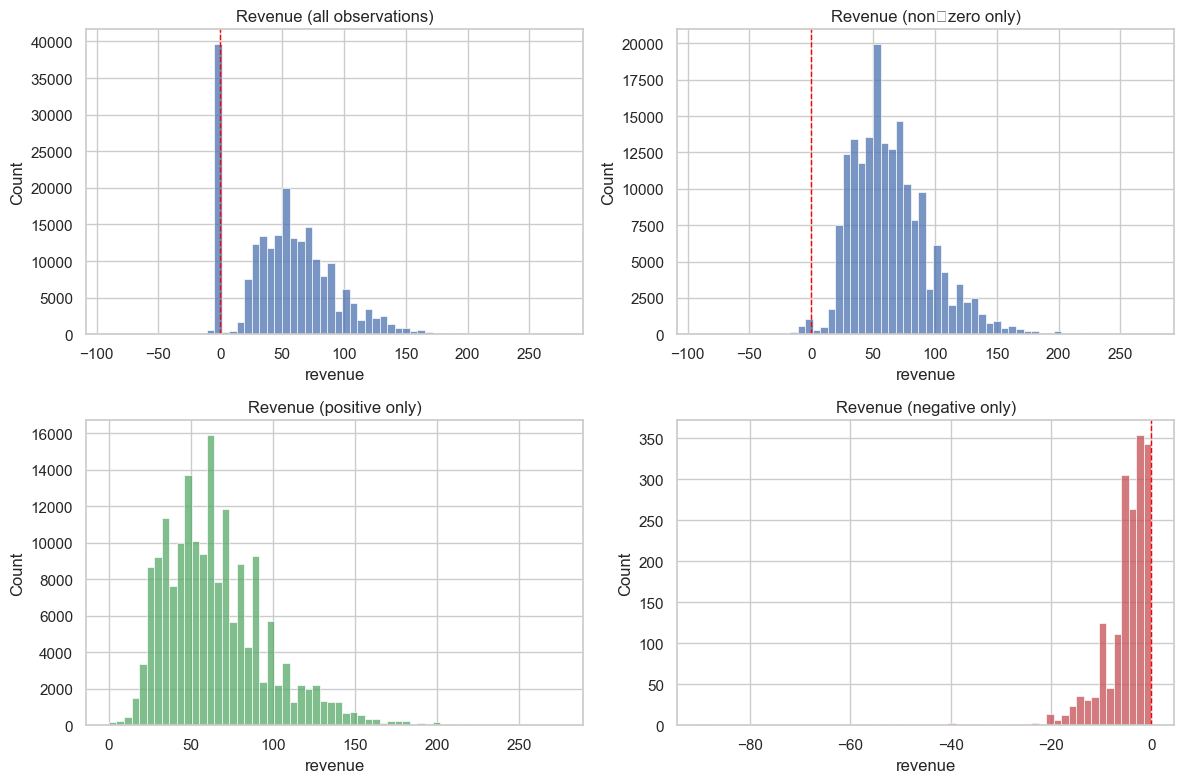

In [9]:
df["revenue"] = df["sale_revenue"].astype(float)

# Convenience flags
df["is_zero_revenue"] = df["revenue"].eq(0)
df["is_returned"] = df["returned_to_shop_id"].notna() & (df["returned_to_shop_id"].astype(str) != "")

# Masks
mask_all       = df["revenue"].notna()
mask_nonzero   = mask_all & ~df["is_zero_revenue"]
mask_positive  = mask_all & (df["revenue"] > 0)
mask_negative  = mask_all & (df["revenue"] < 0)

# Numeric summaries
def quick_stats(series, name):
    s = pd.Series(series).dropna()
    if s.empty:
        print(f"\n{name}: (empty)")
        return
    q = s.quantile([.25, .5, .75])
    print(f"\n{name}: n={len(s):,} | min={s.min():.2f} | p25={q.iloc[0]:.2f} | "
          f"median={q.iloc[1]:.2f} | mean={s.mean():.2f} | p75={q.iloc[2]:.2f} | max={s.max():.2f}")
    
print("Columns:", df.columns.tolist())
quick_stats(df.loc[mask_all, "revenue"],      "Revenue (all)")
quick_stats(df.loc[mask_nonzero, "revenue"],  "Revenue (non-zero)")
quick_stats(df.loc[mask_positive, "revenue"], "Revenue (positive)")
quick_stats(df.loc[mask_negative, "revenue"], "Revenue (negative)")

# --- Plots: 2x2 grid ---
import seaborn as sns
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.ravel()

sns.histplot(df.loc[mask_all, "revenue"], bins=60, ax=axes[0])
axes[0].set_title("Revenue (all observations)")
axes[0].axvline(0, ls="--", c="red", lw=1)

sns.histplot(df.loc[mask_nonzero, "revenue"], bins=60, ax=axes[1])
axes[1].set_title("Revenue (non‑zero only)")
axes[1].axvline(0, ls="--", c="red", lw=1)

sns.histplot(df.loc[mask_positive, "revenue"], bins=60, ax=axes[2], color="#55A868")
axes[2].set_title("Revenue (positive only)")

sns.histplot(df.loc[mask_negative, "revenue"], bins=60, ax=axes[3], color="#C44E52")
axes[3].set_title("Revenue (negative only)")
axes[3].axvline(0, ls="--", c="red", lw=1)

plt.tight_layout()
plt.show()


Left skewed data with large amount of zero revenue items

### Grouped per customer

In [53]:
def analyze_group_distribution(df, group_col, value_col="revenue", agg="sum", bins=60, title_suffix="(sum)"):
    """
    Aggregates df[value_col] by df[group_col] with the chosen agg, then
    shows distributions for all / non-zero / positive / negative.

    agg can be 'sum', 'mean', 'median', etc. (anything pandas groupby supports)
    """
    assert group_col in df.columns, f"{group_col} not in df"
    assert value_col in df.columns, f"{value_col} not in df"

    # Aggregate
    g = (
        df.groupby(group_col, observed=True)[value_col]
          .agg(agg)
          .rename(f"{value_col}_{agg}")
          .to_frame()
          .reset_index()
    )
    metric = g.columns[-1]  # name like "revenue_sum"
    g["is_zero"] = g[metric].eq(0)

    # Masks
    m_all      = g[metric].notna()
    m_nonzero  = m_all & ~g["is_zero"]
    m_positive = m_all & (g[metric] > 0)
    m_negative = m_all & (g[metric] < 0)

    # Stats
    print(f"\n=== {group_col}: distribution of {metric} {title_suffix} ===")
    quick_stats(g.loc[m_all, metric],     f"{metric} - ALL")
    quick_stats(g.loc[m_nonzero, metric], f"{metric} - NONZERO")
    quick_stats(g.loc[m_positive, metric],f"{metric} - POSITIVE")
    quick_stats(g.loc[m_negative, metric],f"{metric} - NEGATIVE")

    # Counts (handy for sanity)
    print({
        "groups_total": int(m_all.sum()),
        "groups_zero": int(g["is_zero"].sum()),
        "groups_positive": int(m_positive.sum()),
        "groups_negative": int(m_negative.sum()),
    })
    print(g)
    # Plots
    fig, axes = plt.subplots(2, 2, figsize=(12, 8))
    axes = axes.ravel()

    sns.histplot(g.loc[m_all, metric],     bins=bins, ax=axes[0])
    axes[0].set_title(f"{group_col}: {metric} (all)")
    axes[0].axvline(0, ls="--", c="red", lw=1)

    sns.histplot(g.loc[m_nonzero, metric], bins=bins, ax=axes[1])
    axes[1].set_title(f"{group_col}: {metric} (non‑zero)")
    axes[1].axvline(0, ls="--", c="red", lw=1)

    sns.histplot(g.loc[m_positive, metric], bins=bins, ax=axes[2], color="#55A868")
    axes[2].set_title(f"{group_col}: {metric} (positive)")

    sns.histplot(g.loc[m_negative, metric], bins=bins, ax=axes[3], color="#C44E52")
    axes[3].set_title(f"{group_col}: {metric} (negative)")
    axes[3].axvline(0, ls="--", c="red", lw=1)

    plt.tight_layout()
    plt.show()

    return g  # return the aggregated table in case you want to reuse it


=== cust_id: distribution of revenue_sum (customer total revenue) ===

revenue_sum - ALL: n=93,272 | min=9.99 | p25=58.96 | median=89.90 | mean=124.87 | p75=145.00 | max=1199.04

revenue_sum - NONZERO: n=93,272 | min=9.99 | p25=58.96 | median=89.90 | mean=124.87 | p75=145.00 | max=1199.04

revenue_sum - POSITIVE: n=93,272 | min=9.99 | p25=58.96 | median=89.90 | mean=124.87 | p75=145.00 | max=1199.04

revenue_sum - NEGATIVE: (empty)
{'groups_total': 93272, 'groups_zero': 0, 'groups_positive': 93272, 'groups_negative': 0}
                cust_id  revenue_sum  is_zero
0      222agnowc53dykbq        89.95    False
1      222ny4m63rmalpdl       125.93    False
2      223xvc4rbjatlnev       116.14    False
3      223y2r357elerbis        47.97    False
4      2245y4r7mgo45qg3       533.92    False
...                 ...          ...      ...
93267  zzybnlwbtkgxlxfp        53.96    False
93268  zzyxpsplvmkbptmr        49.95    False
93269  zzz7uiqp6ouwud4l       116.00    False
93270  zzzs2u

/var/folders/hf/7q1165696l3cv3h97wcgcjxh0000gn/T/ipykernel_1150/2112899398.py:62: UserWarning: Glyph 8209 (\N{NON-BREAKING HYPHEN}) missing from font(s) Arial.
  plt.tight_layout()
/Users/chloe/Library/Python/3.12/lib/python/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8209 (\N{NON-BREAKING HYPHEN}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


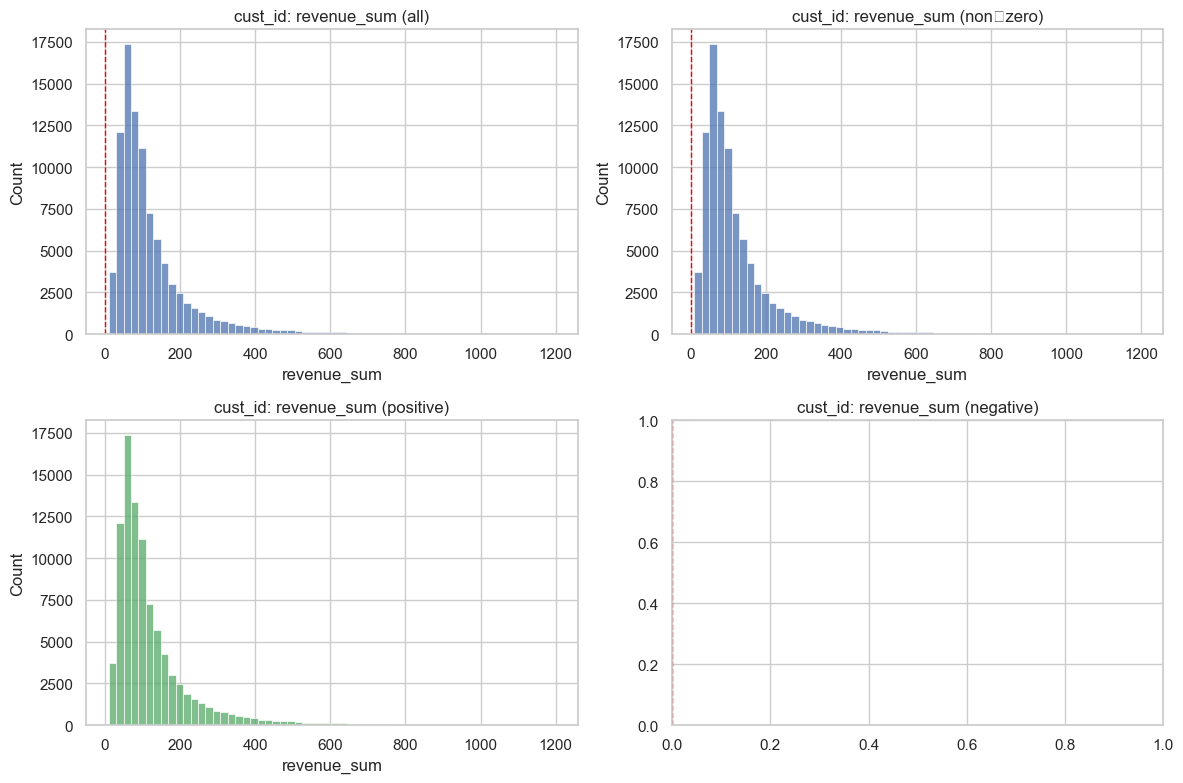

In [54]:

agg_cust = analyze_group_distribution(
    df,
    group_col="cust_id",     # change to your exact customer id col if different
    value_col="revenue",
    agg="sum",
    title_suffix="(customer total revenue)"
)



Grouping per customer (as it is in the target) fixes the negative revenue, reveals a different distribution --> log transformation would help for instance

### Grouped per sale_id


=== sale_id: distribution of revenue_sum (transaction total revenue) ===

revenue_sum - ALL: n=157,247 | min=-135.90 | p25=41.97 | median=65.95 | mean=74.07 | p75=99.00 | max=825.75

revenue_sum - NONZERO: n=142,548 | min=-135.90 | p25=49.98 | median=69.97 | mean=81.70 | p75=100.00 | max=825.75

revenue_sum - POSITIVE: n=142,010 | min=0.00 | p25=49.98 | median=69.97 | mean=82.04 | p75=100.00 | max=825.75

revenue_sum - NEGATIVE: n=538 | min=-135.90 | p25=-10.00 | median=-5.00 | mean=-7.99 | p75=-3.46 | max=-0.00
{'groups_total': 157247, 'groups_zero': 14699, 'groups_positive': 142010, 'groups_negative': 538}


/var/folders/hf/7q1165696l3cv3h97wcgcjxh0000gn/T/ipykernel_1150/2215479194.py:62: UserWarning: Glyph 8209 (\N{NON-BREAKING HYPHEN}) missing from font(s) Arial.
  plt.tight_layout()
/Users/chloe/Library/Python/3.12/lib/python/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8209 (\N{NON-BREAKING HYPHEN}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


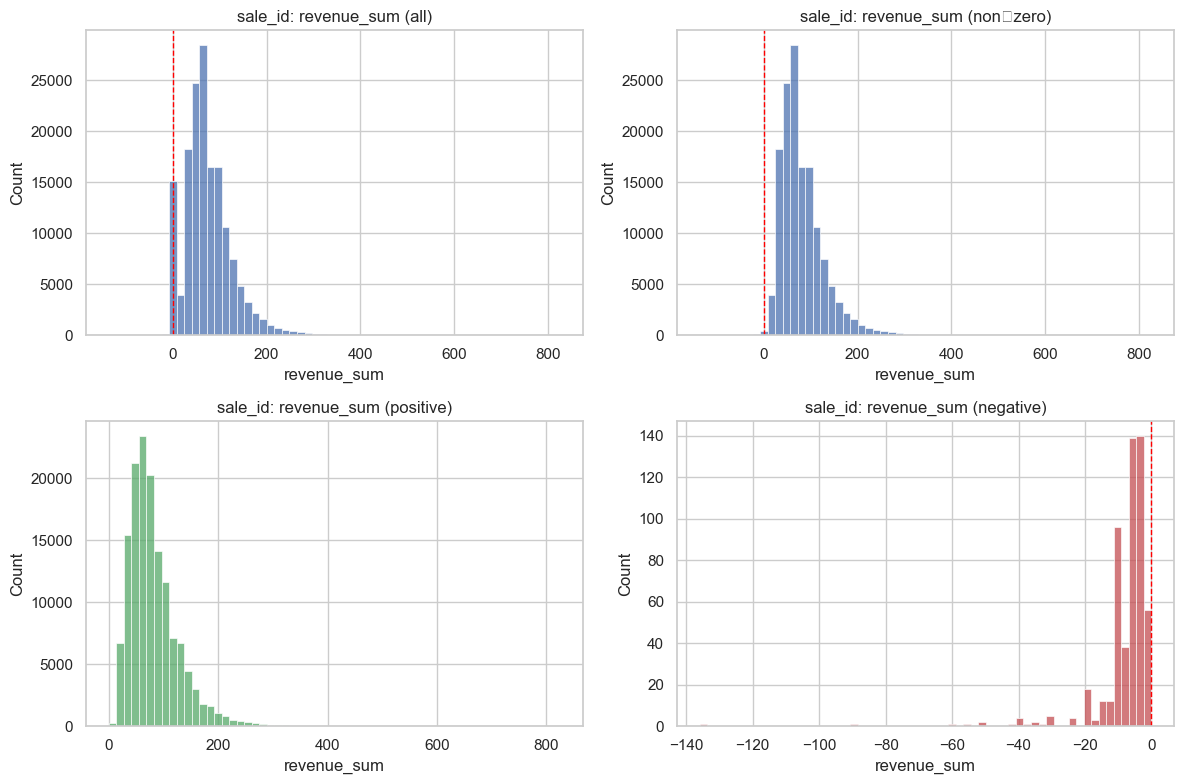

In [12]:
agg_sale = analyze_group_distribution(
    df,
    group_col="sale_id",
    value_col="revenue",
    agg="sum",
    title_suffix="(transaction total revenue)"
)

### Differences in revenue for different categories (item level)

#### Per product color

There are many different colors, and the distribution of revenue differs across these. Maybe making some sort of clusters here would be useful.

##### Count per color category

In [13]:
counts_all     = df.groupby("prod_color", observed=True).size().rename("all")
counts_nonzero = df.loc[mask_nonzero].groupby("prod_color", observed=True).size().rename("nonzero")
counts_pos     = df.loc[mask_positive].groupby("prod_color", observed=True).size().rename("positive")
counts_neg     = df.loc[mask_negative].groupby("prod_color", observed=True).size().rename("negative")

color_counts = (
    pd.concat([counts_all, counts_nonzero, counts_pos, counts_neg], axis=1)
      .fillna(0).astype(int)
      .sort_values("all", ascending=False)
)
display(color_counts.head(41))

(color_counts.div(color_counts.sum()) * 100).round(2)


,all,nonzero,positive,negative
prod_color,,,,
black,39408,32445,32220,225
cognac,29805,24135,23910,225
dark blue,22443,18815,18644,171
white,14630,12208,12059,149
blue,14394,12139,12005,134
pink,12828,10267,10124,143
grey,9222,7874,7817,57
gold,7506,5803,5712,91
taupe,7368,6020,5967,53


,all,nonzero,positive,negative
prod_color,,,,
black,17.98,17.97,18.02,13.02
cognac,13.60,13.37,13.37,13.02
dark blue,10.24,10.42,10.43,9.90
white,6.68,6.76,6.74,8.62
blue,6.57,6.72,6.71,7.75
pink,5.85,5.69,5.66,8.28
grey,4.21,4.36,4.37,3.30
gold,3.43,3.21,3.19,5.27
taupe,3.36,3.33,3.34,3.07


##### Revenue per color

In [14]:
# Per-slice summary tables: TOP 10 by AVERAGE revenue
color_series = df["prod_color"].fillna("Unknown") 

results = {}  # keep the per-slice tables for optional post-hoc

for label, mask in [
    ("all",       mask_all),
    ("nonzero",   mask_nonzero),
    ("positive",  mask_positive),
]:
    # slice and attach color
    s = df.loc[mask, ["revenue"]].copy()
    s["prod_color"] = color_series[mask].values

    # summarize by color, then sort by average revenue (descending)
    tbl = (
        s.groupby("prod_color")["revenue"]
         .agg(rows="size", total="sum", avg="mean", median="median", sd="std")
         .sort_values("avg", ascending=False)
    )
    results[label] = tbl

    print(f"\n=== prod_color — {label}: TOP 10 by average revenue ===")
    display(tbl.head(10))


=== prod_color — all: TOP 10 by average revenue ===


,rows,total,avg,median,sd
prod_color,,,,,
natural,1246,86879.07,69.726380,68.35,48.900978
olive green,232,14977.29,64.557284,59.35,49.616901
cognac,29805,1920565.01,64.437679,66.00,43.765870
black,39408,2333956.38,59.225446,59.95,41.415801
khaki,2404,139310.45,57.949438,55.97,38.764885
dark brown,3701,212160.09,57.325072,55.97,39.042089
brown,5794,330571.36,57.054084,55.50,41.149325
burgundy,2120,116086.88,54.757962,53.95,37.901274
light brown,1523,82174.31,53.955555,53.96,40.237127



=== prod_color — nonzero: TOP 10 by average revenue ===


,rows,total,avg,median,sd
prod_color,,,,,
natural,1071,86879.07,81.119580,75.95,43.096771
cognac,24135,1920565.01,79.575927,75.95,34.070135
olive green,190,14977.29,78.827842,67.15,43.336388
black,32445,2333956.38,71.935780,66.00,34.191178
khaki,2040,139310.45,68.289436,65.00,32.626992
dark brown,3131,212160.09,67.761127,61.55,33.083006
light brown,1219,82174.31,67.411247,62.95,33.396237
brown,4933,330571.36,67.012236,61.00,36.351263
bronze,2769,183366.92,66.221351,62.95,30.019240



=== prod_color — positive: TOP 10 by average revenue ===


,rows,total,avg,median,sd
prod_color,,,,,
natural,1062,86945.02,81.869134,76.01,42.497045
cognac,23910,1921989.72,80.384346,76.76,33.183919
olive green,188,14982.73,79.695372,69.15,42.734422
black,32220,2335045.51,72.471928,66.00,33.694253
khaki,2033,139340.74,68.539469,65.40,32.402597
dark brown,3117,212250.21,68.094389,62.58,32.778007
light brown,1209,82270.68,68.048536,62.95,32.762573
brown,4901,330756.74,67.487603,62.50,35.986116
bronze,2744,183531.85,66.884785,62.95,29.325828


In [15]:
for label, mask in [
    ("all",       mask_all),
    ("nonzero",   mask_nonzero),
    ("positive",  mask_positive),
    ("negative",  mask_negative),
]:
    s = df.loc[mask, ["revenue"]].copy()
    s["prod_color"] = color_series[mask].values

    grouped = s.groupby("prod_color")["revenue"]

    # Keep colors with at least 2 observations to avoid degenerate groups
    groups = [vals.values for _, vals in grouped if len(vals) >= 2]
    k = len(groups)

    if k < 2:
        print(f"\n{label}: Not enough colors with ≥2 observations to run a test.")
        continue

    H, p = sps.kruskal(*groups)
    print(f"\n{label}: Kruskal–Wallis across {k} colors  ->  H={H:.2f}, p={p:.3g}")
    if p < 0.05:
        print("↳ Interpretation: At least one color differs significantly in revenue distribution.")
    else:
        print("↳ Interpretation: No evidence of a difference across colors at α=0.05.")


all: Kruskal–Wallis across 41 colors  ->  H=7597.30, p=0
↳ Interpretation: At least one color differs significantly in revenue distribution.

nonzero: Kruskal–Wallis across 41 colors  ->  H=15134.86, p=0
↳ Interpretation: At least one color differs significantly in revenue distribution.

positive: Kruskal–Wallis across 41 colors  ->  H=15423.67, p=0
↳ Interpretation: At least one color differs significantly in revenue distribution.

negative: Kruskal–Wallis across 36 colors  ->  H=42.34, p=0.184
↳ Interpretation: No evidence of a difference across colors at α=0.05.


#### Per season

Legend: 
* Z & SZ = summer
* SW = summer-winter
* W = winter
* MW = mid - winter (often between seasons)
* MZ = mid - summer (often between seasons)
* NOS = staple items that are produced year-round & rarely go on sale
* CONS =  specially curated, limited, or premium collections
* i'm not sure about SZ & SW

Findings
* Regarding names of seaons: Mid-season & staples lower average revenue, SZ & SW best
* The newer, the higher average revenue with CONS on top
* Significant differences

##### Counts per season category + further categorisation

In [16]:
counts_all     = df.groupby("prod_season", observed=True).size().rename("all")
counts_nonzero = df.loc[mask_nonzero].groupby("prod_season", observed=True).size().rename("nonzero")
counts_pos     = df.loc[mask_positive].groupby("prod_season", observed=True).size().rename("positive")
counts_neg     = df.loc[mask_negative].groupby("prod_season", observed=True).size().rename("negative")

season_counts = (
    pd.concat([counts_all, counts_nonzero, counts_pos, counts_neg], axis=1)
      .fillna(0).astype(int)
      .sort_values("all", ascending=False)
)

display(season_counts.head(41))


,all,nonzero,positive,negative
prod_season,,,,
Z17,55280,45049,44590,459
Z16,55091,45262,44650,612
W16,43834,36301,36052,249
W17,27524,22646,22544,102
W15,18542,15706,15541,165
Z15,6661,5510,5432,78
W14,3603,2834,2811,23
NOS,1652,1488,1478,10
Z14,1624,1312,1295,17


Categorising per year and per season name

In [17]:
# Normalize prod_season to uppercase strings; keep NaN as missing
_s = df["prod_season"].astype("string").str.strip().str.upper()

# Feature 1: letters prefix (e.g., 'Z', 'W', 'MW', 'SZ', 'NOS', 'CONS', …)
df["season_letters"] = _s.str.extract(r'^([A-Z]+)')[0].fillna("Unknown").astype("category")

# Feature 2: year (last digits) OR NOS/CONS; else 'Unknown'
_last_num = _s.str.extract(r'(\d+)$')[0]                      # e.g., '17'
df["season_year_cat"] = np.where(
    df["season_letters"].isin(["NOS", "CONS"]),
    df["season_letters"],
    _last_num
)
df["season_year_cat"] = df["season_year_cat"].fillna("Unknown").astype("category")

##### Revenue per season category

In [18]:
for group_col in ["season_letters", "season_year_cat"]:
    print(f"\n==================== {group_col} ====================")
    for label, mask in [
        ("all",       mask_all),
        ("nonzero",   mask_nonzero),
        ("positive",  mask_positive),
        ("negative",  mask_negative),
    ]:
        # Slice and group
        s = df.loc[mask, [group_col, "revenue"]].copy()
        # Summary per category, sorted by AVERAGE revenue
        tbl = (
            s.groupby(group_col, observed=True)["revenue"]
             .agg(rows="size", total="sum", avg="mean", median="median", sd="std")
             .sort_values("avg", ascending=False)
        )

        print(f"\n--- {group_col} · {label} · TOP 10 by average revenue ---")
        display(tbl.head(10))

        # Global significance test across categories (Kruskal–Wallis)
        grouped = s.groupby(group_col)["revenue"]
        groups = [vals.values for _, vals in grouped if len(vals) >= 2]  # avoid 1‑obs groups
        if len(groups) >= 2:
            H, p = stats.kruskal(*groups)
            print(f"{group_col} · {label}: Kruskal–Wallis H={H:.2f}, p={p:.3g}")
            if p < 0.05:
                print("↳ At least one season category differs significantly.")
            else:
                print("↳ No evidence of differences at α=0.05.")
        else:
            print(f"{group_col} · {label}: Not enough categories with ≥2 rows to test.")


==================== season_letters ====================

--- season_letters · all · TOP 10 by average revenue ---


,rows,total,avg,median,sd
season_letters,,,,,
SW,523,54197.85,103.628776,130.00,59.947673
SZ,561,47884.69,85.355954,94.50,52.021135
CONS,301,24128.88,80.162392,99.00,51.295740
W,94601,5496415.09,58.101025,56.00,41.728241
Z,119557,5925315.27,49.560588,50.35,34.228443
NOS,1652,52651.83,31.871568,27.95,21.045204
MW,1276,34969.01,27.405180,29.95,12.552422
MZ,657,11271.84,17.156530,19.95,8.938652


season_letters · all: Kruskal–Wallis H=5198.12, p=0
↳ At least one season category differs significantly.

--- season_letters · nonzero · TOP 10 by average revenue ---


,rows,total,avg,median,sd
season_letters,,,,,
SW,408,54197.85,132.837868,135.000,26.824285
SZ,431,47884.69,111.101369,112.000,25.638813
CONS,247,24128.88,97.687773,108.000,38.598836
W,78392,5496415.09,70.114490,65.000,35.481783
Z,97911,5925315.27,60.517360,56.960,27.704145
NOS,1488,52651.83,35.384294,28.955,19.166867
MW,1093,34969.01,31.993605,29.950,6.085513
MZ,578,11271.84,19.501453,19.950,6.710460


season_letters · nonzero: Kruskal–Wallis H=9701.24, p=0
↳ At least one season category differs significantly.

--- season_letters · positive · TOP 10 by average revenue ---


...

season_year_cat · nonzero: Kruskal–Wallis H=7384.00, p=0
↳ At least one season category differs significantly.

--- season_year_cat · positive · TOP 10 by average revenue ---


,rows,total,avg,median,sd
season_year_cat,,,,,
CONS,245,24136.21,98.515143,108.50,37.645602
17,69416,4790474.77,69.011104,62.95,32.387496
16,80841,5273138.07,65.228511,59.97,30.248305
18,534,33851.18,63.391723,59.95,25.595948
15,21036,1263347.58,60.056455,55.97,30.849434
14,4123,184347.00,44.711860,39.00,26.262833
NOS,1478,52689.70,35.649323,29.95,18.957339
13,1095,33178.68,30.300164,26.00,18.248575
12,52,856.87,16.478269,15.00,8.050223


season_year_cat · positive: Kruskal–Wallis H=7562.95, p=0
↳ At least one season category differs significantly.

--- season_year_cat · negative · TOP 10 by average revenue ---


,rows,total,avg,median,sd
season_year_cat,,,,,
13,5,-14.13,-2.826000,-2.510,1.569054
CONS,2,-7.33,-3.665000,-3.665,0.940452
NOS,10,-37.87,-3.787000,-3.330,1.645479
15,243,-1133.84,-4.666008,-3.070,4.715126
14,40,-188.90,-4.722500,-2.565,4.491306
18,1,-5.00,-5.000000,-5.000,NaN
16,861,-4644.81,-5.394669,-3.850,6.054477
17,566,-3153.72,-5.571943,-4.620,6.420191


season_year_cat · negative: Kruskal–Wallis H=14.64, p=0.0232
↳ At least one season category differs significantly.


#### Per primary target group

There are significant age & gender differences, with average revenue being higher for female gendered items than male, and same for clothes for adults, but adult men actually being the highest

##### Counts & further categorization

In [19]:
counts_all     = df.groupby("prod_type_1", observed=True).size().rename("all")
counts_nonzero = df.loc[mask_nonzero].groupby("prod_type_1", observed=True).size().rename("nonzero")
counts_pos     = df.loc[mask_positive].groupby("prod_type_1", observed=True).size().rename("positive")
counts_neg     = df.loc[mask_negative].groupby("prod_type_1", observed=True).size().rename("negative")

agegender_counts = (
    pd.concat([counts_all, counts_nonzero, counts_pos, counts_neg], axis=1)
      .fillna(0).astype(int)
      .sort_values("all", ascending=False)
)
display(agegender_counts.head(41))

,all,nonzero,positive,negative
prod_type_1,,,,
women,118891,95650,94941,709
boys,35352,30055,29678,377
men,34794,30190,30040,150
girls,30091,24653,24161,492


Grouping children vs adults & women vs men

In [41]:
t1 = df["prod_type_1"].astype("string").str.strip().str.lower()

# Exact mapping (only these four)
df["gender_cat"] = (
    t1.map({"men":"male", "women":"female", "boys":"male", "girls":"female"})
      .fillna("unknown")
      .astype("category")
)

df["age_cat"] = (
    t1.map({"men":"adult", "women":"adult", "boys":"child", "girls":"child"})
      .fillna("unknown")
      .astype("category")
)

##### Revenue per age/gender category

In [21]:
# ---- Normalized categorical views (short, inline) ----
t1 = df["prod_type_1"].astype("string").str.strip().str.lower()

# Four explicit categories straight from prod_type_1
t1_4 = t1.where(t1.isin(["boys","girls","men","women"]))

# Gender & age derived only for the two-way tests (still from prod_type_1)
gender_from_t1 = t1.map({"men":"male","women":"female","boys":"male","girls":"female"})
age_from_t1    = t1.map({"men":"adult","women":"adult","boys":"child","girls":"child"})

for label, m in [
    ("all",       mask_all),
    ("nonzero",   mask_nonzero),
    ("positive",  mask_positive),
    ("negative",  mask_negative),
]:
    print(f"\n================ {label.upper()} ================")

    # -------- A) FOUR CATEGORIES: boys / girls / men / women (no other buckets) --------
    s4 = pd.DataFrame({
        "grp": t1_4[m], 
        "revenue": df.loc[m, "revenue"].values
    }).dropna(subset=["grp"])

    tbl4 = (
        s4.groupby("grp", observed=True)["revenue"]
          .agg(rows="size", total="sum", avg="mean", median="median", sd="std")
          .sort_values("avg", ascending=False)
    )
    print("\n--- prod_type_1 (boys/girls/men/women) ---")
    display(tbl4)

    # Kruskal–Wallis across the groups present (require ≥2 rows each)
    counts4 = s4["grp"].value_counts()
    cats4   = counts4[counts4 >= 2].index.tolist()
    groups4 = [s4.loc[s4["grp"] == c, "revenue"].values for c in cats4]
    if len(cats4) >= 2:
        H, p = stats.kruskal(*groups4)
        print(f"Kruskal–Wallis over {cats4}: H={H:.2f}, p={p:.3g}")
    else:
        print("Four-cat test: not enough categories (need ≥2 rows per category).")

    # -------- B) GENDER (male vs female) --------
    sg = pd.DataFrame({
        "gender": gender_from_t1[m],
        "revenue": df.loc[m, "revenue"].values
    }).dropna(subset=["gender"])
    # Summary
    tblg = (
        sg.groupby("gender", observed=True)["revenue"]
          .agg(rows="size", total="sum", avg="mean", median="median", sd="std")
          .sort_values("avg", ascending=False)
    )
    print("\n--- gender (male vs female) ---")
    display(tblg)
    # Test (two groups, require ≥2 rows each)
    if all((sg["gender"] == g).sum() >= 2 for g in ["male","female"]):
        g1 = sg.loc[sg["gender"] == "male", "revenue"].values
        g2 = sg.loc[sg["gender"] == "female", "revenue"].values
        u, p = stats.mannwhitneyu(g1, g2, alternative="two-sided")
        print(f"Mann–Whitney (male vs female): U={u:.1f}, p={p:.3g} | "
              f"Δmean={g1.mean()-g2.mean():.2f}, Δmedian={np.median(g1)-np.median(g2):.2f}")
    else:
        print("Gender test: not enough rows (need ≥2 in each group).")

    # -------- C) AGE (adult vs child) --------
    sa = pd.DataFrame({
        "age": age_from_t1[m],
        "revenue": df.loc[m, "revenue"].values
    }).dropna(subset=["age"])
    tbla = (
        sa.groupby("age", observed=True)["revenue"]
          .agg(rows="size", total="sum", avg="mean", median="median", sd="std")
          .sort_values("avg", ascending=False)
    )
    print("\n--- age (adult vs child) ---")
    display(tbla)
    if all((sa["age"] == a).sum() >= 2 for a in ["adult","child"]):
        a1 = sa.loc[sa["age"] == "adult", "revenue"].values
        a2 = sa.loc[sa["age"] == "child", "revenue"].values
        u, p = stats.mannwhitneyu(a1, a2, alternative="two-sided")
        print(f"Mann–Whitney (adult vs child): U={u:.1f}, p={p:.3g} | "
              f"Δmean={a1.mean()-a2.mean():.2f}, Δmedian={np.median(a1)-np.median(a2):.2f}")
    else:
        print("Age test: not enough rows (need ≥2 in each group).")


================ ALL ================

--- prod_type_1 (boys/girls/men/women) ---


,rows,total,avg,median,sd
grp,,,,,
men,34794,2127542.31,61.146816,60.00,38.956757
women,118891,6703780.40,56.385937,55.97,40.860727
girls,30091,1319059.63,43.835686,42.98,31.488502
boys,35352,1496452.12,42.330055,39.98,27.656789


Kruskal–Wallis over ['women', 'boys', 'men', 'girls']: H=7489.81, p=0

--- gender (male vs female) ---


,rows,total,avg,median,sd
gender,,,,,
female,148982,8022840.03,53.851069,53.95,39.471810
male,70146,3623994.43,51.663594,49.98,35.025226


Mann–Whitney (male vs female): U=5030739107.5, p=2.9e-45 | Δmean=-2.19, Δmedian=-3.97

--- age (adult vs child) ---


...

Kruskal–Wallis over ['women', 'girls', 'boys', 'men']: H=45.73, p=6.48e-10

--- gender (male vs female) ---


,rows,total,avg,median,sd
gender,,,,,
male,527,-2665.31,-5.057514,-4.11,4.956801
female,1201,-6520.29,-5.429051,-3.89,6.341676


Mann–Whitney (male vs female): U=318747.5, p=0.811 | Δmean=0.37, Δmedian=-0.22

--- age (adult vs child) ---


,rows,total,avg,median,sd
age,,,,,
adult,859,-3992.37,-4.647695,-3.34,6.395807
child,869,-5193.23,-5.976099,-4.60,5.406792


Mann–Whitney (adult vs child): U=439042.0, p=2.21e-10 | Δmean=1.33, Δmedian=1.26


#### Per shoe size

Significant but small explanatory value: bigger sizes = more revenue on average

Mean shoe size: 36.89

== Shoe size × revenue · all ==  n=219128
Pearson r=0.165, p=0  |  Spearman ρ=0.153, p=0
Slope €/size-unit (centered): 1.09  [95% CI 1.06, 1.12],  p=0,  R²=0.027


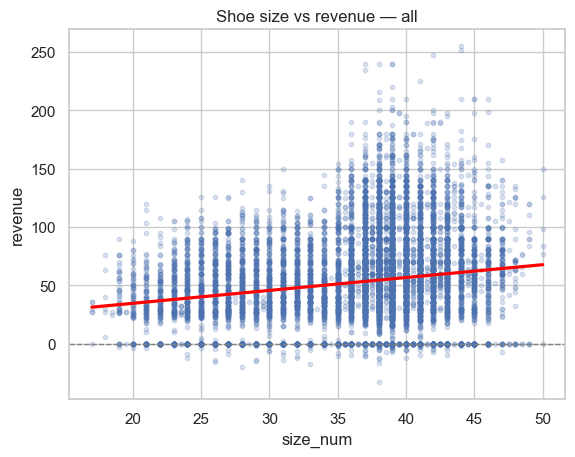


== Shoe size × revenue · nonzero ==  n=180548
Pearson r=0.233, p=0  |  Spearman ρ=0.215, p=0
Slope €/size-unit (centered): 1.30  [95% CI 1.27, 1.32],  p=0,  R²=0.054


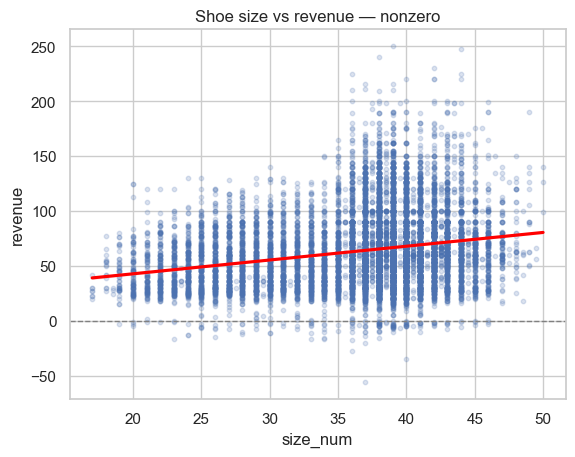


== Shoe size × revenue · positive ==  n=178820
Pearson r=0.232, p=0  |  Spearman ρ=0.214, p=0
Slope €/size-unit (centered): 1.27  [95% CI 1.24, 1.29],  p=0,  R²=0.054


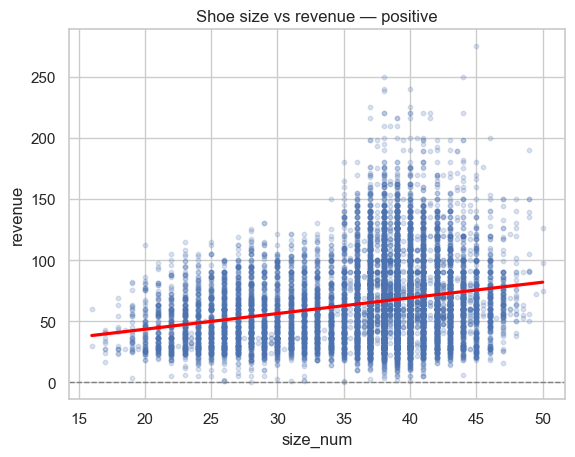


== Shoe size × revenue · negative ==  n=1728
Pearson r=0.089, p=0.000209  |  Spearman ρ=0.132, p=3.42e-08
Slope €/size-unit (centered): 0.08  [95% CI 0.04, 0.13],  p=0.000209,  R²=0.008


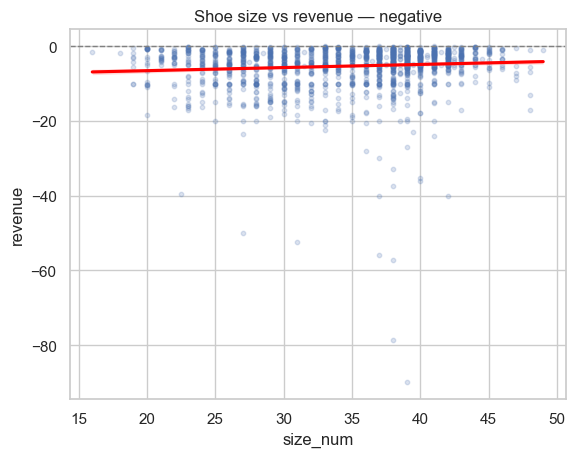

In [ ]:
# Numeric + centered size
df["size_num"] = pd.to_numeric(df["prod_size"], errors="coerce")
mu = df["size_num"].mean(skipna=True)
df["size_c"] = df["size_num"] - mu
print(f"Mean shoe size: {mu:.2f}")

# Correlation + regression per mask
for label, m in [
    ("all",       mask_all),
    ("nonzero",   mask_nonzero),
    ("positive",  mask_positive),
    ("negative",  mask_negative),
]:
    s = df.loc[m, ["size_num", "size_c", "revenue"]].dropna(subset=["size_num", "revenue"])
    n = len(s)
    print(f"\n== Shoe size x revenue · {label} ==  n={n}")
    if n < 3 or s["size_num"].nunique() < 2:
        print("Not enough variation in size to test.")
        continue

    # Correlations
    r_pear, p_pear   = stats.pearsonr(s["size_num"], s["revenue"])
    r_spear, p_spear = stats.spearmanr(s["size_num"], s["revenue"])

    # Linear regression: revenue ~ centered size
    lr = stats.linregress(s["size_c"], s["revenue"])
    ci_low, ci_high = lr.slope - 1.96*lr.stderr, lr.slope + 1.96*lr.stderr

    print(f"Pearson r={r_pear:.3f}, p={p_pear:.3g}  |  Spearman ρ={r_spear:.3f}, p={p_spear:.3g}")
    print(f"Slope €/size-unit (centered): {lr.slope:.2f}  [95% CI {ci_low:.2f}, {ci_high:.2f}]"
          f",  p={lr.pvalue:.3g},  R²={lr.rvalue**2:.3f}")

    # (Optional) quick visual – comment out if you don't need plots
    s_plot = s.sample(n=min(15000, n), random_state=0)
    sns.regplot(data=s_plot, x="size_num", y="revenue",
                 scatter_kws={"alpha":0.2, "s":10}, line_kws={"color":"red"})
    plt.title(f"Shoe size vs revenue — {label}")
    plt.axhline(0, color="gray", lw=1, ls="--"); plt.show()

#### Per secondary product category

Should be recategorised as categories overlap and there are plenty with low counts.

##### Counts

In [23]:
print("Amount of unique values:", df["prod_type_3"].nunique(dropna=False))

counts_all     = df.groupby("prod_type_3", observed=True).size().rename("all")
counts_nonzero = df.loc[mask_nonzero].groupby("prod_type_3", observed=True).size().rename("nonzero")
counts_pos     = df.loc[mask_positive].groupby("prod_type_3", observed=True).size().rename("positive")
counts_neg     = df.loc[mask_negative].groupby("prod_type_3", observed=True).size().rename("negative")

seccat_counts = (
    pd.concat([counts_all, counts_nonzero, counts_pos, counts_neg], axis=1)
      .fillna(0).astype(int)
      .sort_values("all", ascending=False)
)
display(seccat_counts)


Amount of unique values: 40


,all,nonzero,positive,negative
prod_type_3,,,,
sneakers,43828,36949,36654,295
sandals,29266,23009,22697,312
low shoes,26637,21786,21588,198
high shoes,19906,16829,16659,170
ankle boots,19238,15490,15391,99
pumps,18624,14269,14121,148
boots,13522,10708,10596,112
flip-flops,12005,10729,10681,48
slippers,9514,8543,8508,35


##### Revenue

Did select to have at least 100, as those low count categories were dominating (did not do signifance check yet)

In [24]:
# Prepare the categorical series once
pt3 = df["prod_type_3"].fillna("Unknown")

results = {}

for label, mask in [
    ("all",       mask_all),
    ("nonzero",   mask_nonzero),
    ("positive",  mask_positive),
]:
    s = df.loc[mask, ["revenue"]].copy()
    s["prod_type_3"] = pt3[mask].values

    # First compute counts per category in this slice
    counts = s["prod_type_3"].value_counts()

    # Keep only categories with >= 100 rows in THIS slice
    keep_cats = counts[counts >= 100].index
    s = s[s["prod_type_3"].isin(keep_cats)]

    # Summarize and sort by average revenue (desc), then show Top-10
    tbl = (
        s.groupby("prod_type_3", observed=True)["revenue"]
         .agg(rows="size", total="sum", avg="mean", median="median", sd="std")
         .sort_values("avg", ascending=False)
    )
    results[label] = tbl

    print(f"\n=== prod_type_3 — {label}: TOP 10 by average revenue (≥100 rows per category) ===")
    display(tbl.head(10))


=== prod_type_3 — all: TOP 10 by average revenue (≥100 rows per category) ===


,rows,total,avg,median,sd
prod_type_3,,,,,
dress shoes,4179,331149.31,79.241280,77.36,49.637524
"ankle boots, sneakers",400,30324.40,75.811000,80.95,46.017215
"low shoes, pumps",160,11850.27,74.064188,87.75,47.092458
ankle boots,19238,1279969.68,66.533407,67.50,47.569855
boots,13522,854393.41,63.185432,62.95,49.760296
low shoes,26637,1611049.21,60.481631,62.95,39.556014
"high shoes, low shoes",116,6995.81,60.308707,69.97,36.685307
high shoes,19906,1200433.09,60.305088,60.17,38.027605
"ankle boots, boots",602,35028.84,58.187442,59.95,45.395322



=== prod_type_3 — nonzero: TOP 10 by average revenue (≥100 rows per category) ===


,rows,total,avg,median,sd
prod_type_3,,,,,
dress shoes,3541,331149.31,93.518585,82.500,39.653110
"ankle boots, sneakers",325,30324.40,93.305846,89.950,31.150536
"low shoes, pumps",128,11850.27,92.580234,99.950,32.384755
ankle boots,15490,1279969.68,82.632000,78.000,38.472283
boots,10708,854393.41,79.790195,77.350,42.447945
"ankle boots, boots",468,35028.84,74.847949,76.455,37.448141
low shoes,21786,1611049.21,73.948830,69.970,30.284740
high shoes,16829,1200433.09,71.331219,68.350,30.396773
pumps,14269,984281.67,68.980424,62.950,31.090092



=== prod_type_3 — positive: TOP 10 by average revenue (≥100 rows per category) ===


,rows,total,avg,median,sd
prod_type_3,,,,,
dress shoes,3521,331220.37,94.069972,84.00,39.082151
"ankle boots, sneakers",325,30324.40,93.305846,89.95,31.150536
"low shoes, pumps",128,11850.27,92.580234,99.95,32.384755
ankle boots,15391,1280468.82,83.195947,79.95,37.941272
boots,10596,855318.70,80.720904,78.00,41.684146
"ankle boots, boots",462,35041.02,75.846364,76.76,36.642250
low shoes,21588,1612303.65,74.685179,69.97,29.418409
high shoes,16659,1201551.99,72.126297,68.36,29.503257
pumps,14121,984844.72,69.743270,62.95,30.337362


#### Web/nonweb

Significant difference with web having higher revenue

##### Counts

In [25]:
counts_all     = df.groupby("prod_web_only", observed=True).size().rename("all")
counts_nonzero = df.loc[mask_nonzero].groupby("prod_web_only", observed=True).size().rename("nonzero")
counts_pos     = df.loc[mask_positive].groupby("prod_web_only", observed=True).size().rename("positive")
counts_neg     = df.loc[mask_negative].groupby("prod_web_only", observed=True).size().rename("negative")

color_counts = (
    pd.concat([counts_all, counts_nonzero, counts_pos, counts_neg], axis=1)
      .fillna(0).astype(int)
      .sort_values("all", ascending=False)
)
display(color_counts.head(41))

,all,nonzero,positive,negative
prod_web_only,,,,
0,168936,140646,139331,1315
1,50192,39902,39489,413


##### Revenue per web/nonweb

In [26]:
webcol = "prod_web_only" if "prod_web_only" in df.columns else "prob_web_only"

for label, m in [
    ("all",       mask_all),
    ("nonzero",   mask_nonzero),
    ("positive",  mask_positive),
    ("negative",  mask_negative),  # drop this line if you don't want returns slice
]:
    s = pd.DataFrame({
        # map 0/1 OR False/True to readable labels
        "grp": df.loc[m, webcol].map({0:"store_only", 1:"web_only", False:"store_only", True:"web_only"}),
        "rev": df.loc[m, "revenue"].values
    }).dropna(subset=["grp"])

    # summary per group
    tbl = (
        s.groupby("grp", observed=True)["rev"]
         .agg(rows="size", total="sum", avg="mean", median="median", sd="std")
         .sort_values("avg", ascending=False)
    )
    print(f"\n--- {webcol} · {label} ---")
    display(tbl)

    # Mann–Whitney U (need ≥2 rows in each group)
    if all((s["grp"] == g).sum() >= 2 for g in ["store_only", "web_only"]):
        a = s.loc[s["grp"] == "store_only", "rev"].values
        b = s.loc[s["grp"] == "web_only",  "rev"].values
        u, p = stats.mannwhitneyu(a, b, alternative="two-sided")
        print(f"Mann–Whitney (web_only vs store_only): U={u:.1f}, p={p:.3g} | "
              f"Δmean={b.mean()-a.mean():.2f}, Δmedian={np.median(b)-np.median(a):.2f}")
    else:
        print("Significance test: need ≥2 rows in each group.")



--- prod_web_only · all ---


,rows,total,avg,median,sd
grp,,,,,
web_only,50192,2860432.77,56.989815,56.00,41.475618
store_only,168936,8786401.69,52.010239,50.36,36.985940


Mann–Whitney (web_only vs store_only): U=3914810281.5, p=5.09e-151 | Δmean=4.98, Δmedian=5.64

--- prod_web_only · nonzero ---


,rows,total,avg,median,sd
grp,,,,,
web_only,39902,2860432.77,71.686451,65.95,33.320821
store_only,140646,8786401.69,62.471750,59.35,31.457337


Mann–Whitney (web_only vs store_only): U=2323858471.5, p=0 | Δmean=9.21, Δmedian=6.60

--- prod_web_only · positive ---


,rows,total,avg,median,sd
grp,,,,,
web_only,39489,2862840.50,72.497164,66.00,32.523870
store_only,139331,8793179.56,63.110001,59.35,30.904058


Mann–Whitney (web_only vs store_only): U=2266018447.0, p=0 | Δmean=9.39, Δmedian=6.65

--- prod_web_only · negative ---


,rows,total,avg,median,sd
grp,,,,,
store_only,1315,-6777.87,-5.154274,-3.61,5.377238
web_only,413,-2407.73,-5.829855,-4.40,7.487400


Mann–Whitney (web_only vs store_only): U=296321.5, p=0.00509 | Δmean=-0.68, Δmedian=-0.79


#### Outlet

Outlet items have significantly higher revenue (makes sense bc outlet versions only exist of more higher up brands)

##### Counts

In [27]:
counts_all     = df.groupby("prod_outlet", observed=True).size().rename("all")
counts_nonzero = df.loc[mask_nonzero].groupby("prod_outlet", observed=True).size().rename("nonzero")
counts_pos     = df.loc[mask_positive].groupby("prod_outlet", observed=True).size().rename("positive")
counts_neg     = df.loc[mask_negative].groupby("prod_outlet", observed=True).size().rename("negative")

outlet_counts = (
    pd.concat([counts_all, counts_nonzero, counts_pos, counts_neg], axis=1)
      .fillna(0).astype(int)
      .sort_values("all", ascending=False)
)
display(outlet_counts.head(2))

,all,nonzero,positive,negative
prod_outlet,,,,
0,218899,180366,178639,1727
1,229,182,181,1


##### Revenue

In [28]:
# Map to readable labels (supports 0/1 or booleans). Keeps NaN out of test by dropping 'grp' NaNs.
for label, m in [
    ("all",       mask_all),
    ("nonzero",   mask_nonzero),
    ("positive",  mask_positive),
    ("negative",  mask_negative),
]:
    grp = df.loc[m, "prod_outlet"].map({0:"non_outlet", 1:"outlet", False:"non_outlet", True:"outlet"})
    rev = df.loc[m, "revenue"]

    s = pd.DataFrame({"grp": grp, "rev": rev}).dropna(subset=["grp"])

    # Summary
    tbl = (s.groupby("grp", observed=True)["rev"]
             .agg(rows="size", total="sum", avg="mean", median="median", sd="std")
             .sort_values("avg", ascending=False))
    print(f"\n--- prod_outlet · {label} ---")
    display(tbl)

    # Mann–Whitney U (need ≥2 rows in each group)
    n_non = (s["grp"] == "non_outlet").sum()
    n_out = (s["grp"] == "outlet").sum()
    if n_non >= 2 and n_out >= 2:
        a = s.loc[s["grp"] == "non_outlet", "rev"].to_numpy()
        b = s.loc[s["grp"] == "outlet",     "rev"].to_numpy()
        u, p = stats.mannwhitneyu(a, b, alternative="two-sided")
        print(f"Mann–Whitney (outlet vs non_outlet): U={u:.1f}, p={p:.3g} | "
              f"Δmean={b.mean()-a.mean():.2f}, Δmedian={np.median(b)-np.median(a):.2f}")
    else:
        print("Significance test: need ≥2 rows in each group.")


--- prod_outlet · all ---


,rows,total,avg,median,sd
grp,,,,,
outlet,229,13671.59,59.701266,62.95,45.461832
non_outlet,218899,11633162.87,53.143974,53.00,38.109597


Mann–Whitney (outlet vs non_outlet): U=23204749.5, p=0.0513 | Δmean=6.56, Δmedian=9.95

--- prod_outlet · nonzero ---


,rows,total,avg,median,sd
grp,,,,,
outlet,182,13671.59,75.118626,69.95,37.933178
non_outlet,180366,11633162.87,64.497538,59.95,32.098866


Mann–Whitney (outlet vs non_outlet): U=13864658.0, p=0.000287 | Δmean=10.62, Δmedian=10.00

--- prod_outlet · positive ---


,rows,total,avg,median,sd
grp,,,,,
outlet,181,13676.59,75.561271,69.95,37.564104
non_outlet,178639,11642343.47,65.172462,59.97,31.502075


Mann–Whitney (outlet vs non_outlet): U=13684940.0, p=0.000349 | Δmean=10.39, Δmedian=9.98

--- prod_outlet · negative ---


,rows,total,avg,median,sd
grp,,,,,
outlet,1,-5.0,-5.000000,-5.00,NaN
non_outlet,1727,-9180.6,-5.315924,-3.98,5.956313


Significance test: need ≥2 rows in each group.


#### Per brand

486 brands, with many having low counts --> probably need to be clustered? Also this dataset is clearly local, and I could help with interpreting clusters (e.g. Bumba & K3 are both childrens' brands under the same company)

##### Counts

In [29]:
print("Amount of unique values:", df["prod_brand"].nunique(dropna=False))

counts_all     = df.groupby("prod_brand", observed=True).size().rename("all")
counts_nonzero = df.loc[mask_nonzero].groupby("prod_brand", observed=True).size().rename("nonzero")
counts_pos     = df.loc[mask_positive].groupby("prod_brand", observed=True).size().rename("positive")
counts_neg     = df.loc[mask_negative].groupby("prod_brand", observed=True).size().rename("negative")

brand_counts = (
    pd.concat([counts_all, counts_nonzero, counts_pos, counts_neg], axis=1)
      .fillna(0).astype(int)
      .sort_values("all", ascending=False)
)
display(brand_counts.head(30))

Amount of unique values: 486


,all,nonzero,positive,negative
prod_brand,,,,
Gabor,12906,10073,9984,89
Tamaris,11142,8988,8919,69
Geox,8616,7275,7197,78
STONES and BONES,7458,6116,5976,140
Converse,6771,5794,5739,55
Nike,5753,4918,4883,35
Tommy Hilfiger,5653,4743,4707,36
adidas,5449,4721,4669,52
River Woods,4877,3861,3826,35


##### Revenue

Did select to have at least 100, as those low count categories were dominating (did not do signifance check yet)

In [30]:
# Prepare the categorical series once
pt3 = df["prod_brand"].fillna("Unknown")

results = {}

for label, mask in [
    ("all",       mask_all),
    ("nonzero",   mask_nonzero),
    ("positive",  mask_positive),
]:
    s = df.loc[mask, ["revenue"]].copy()
    s["prod_brand"] = pt3[mask].values

    # First compute counts per category in this slice
    counts = s["prod_brand"].value_counts()

    # Keep only categories with >= 100 rows in THIS slice
    keep_cats = counts[counts >= 100].index
    s = s[s["prod_brand"].isin(keep_cats)]

    # Summarize and sort by average revenue (desc), then show Top-10
    tbl = (
        s.groupby("prod_brand", observed=True)["revenue"]
         .agg(rows="size", total="sum", avg="mean", median="median", sd="std")
         .sort_values("avg", ascending=False)
    )
    results[label] = tbl

    print(f"\n=== prod_brand — {label}: TOP 10 by average revenue (≥100 rows per category) ===")
    display(tbl.head(10))


=== prod_brand — all: TOP 10 by average revenue (≥100 rows per category) ===


,rows,total,avg,median,sd
prod_brand,,,,,
Ambiorix,318,48240.05,151.698270,165.115,71.332921
Hugo Boss,227,24548.07,108.141278,120.000,47.706366
Giorgio,156,16720.11,107.180192,114.750,53.762479
Dr. Martens,575,57863.07,100.631426,99.000,46.442620
Van Lier,144,14061.31,97.647986,105.000,56.926968
Rehab,109,10559.99,96.880642,108.000,56.007094
Mephisto,777,74473.94,95.848057,104.000,53.495102
Caterpillar,229,21705.93,94.785721,101.500,40.253659
Ted Baker,435,41173.84,94.652506,121.500,54.206366



=== prod_brand — nonzero: TOP 10 by average revenue (≥100 rows per category) ===


,rows,total,avg,median,sd
prod_brand,,,,,
Ambiorix,274,48240.05,176.058577,168.0,40.049231
Giorgio,133,16720.11,125.715113,122.5,32.345990
Lodi,119,14785.49,124.247815,130.0,39.345277
Hugo Boss,198,24548.07,123.980152,120.0,25.243887
Van Lier,116,14061.31,121.218190,119.5,33.878203
Nathan-Baume,190,22339.67,117.577211,126.0,30.058878
NeroGiardini,2876,333829.89,116.074371,117.0,28.043841
Ted Baker,356,41173.84,115.656854,126.0,34.001060
Wolky,132,14952.31,113.275076,105.0,37.193324



=== prod_brand — positive: TOP 10 by average revenue (≥100 rows per category) ===


,rows,total,avg,median,sd
prod_brand,,,,,
Ambiorix,273,48245.79,176.724505,168.0,38.573082
Lodi,117,14814.91,126.623162,130.0,35.122094
Giorgio,133,16720.11,125.715113,122.5,32.345990
Hugo Boss,197,24551.65,124.627665,120.0,23.602233
Van Lier,115,14061.76,122.276174,120.0,32.044018
Nathan-Baume,189,22341.92,118.211217,126.0,28.836830
Ted Baker,352,41190.94,117.019716,126.0,31.677152
NeroGiardini,2862,333903.13,116.667760,117.0,26.792659
Wolky,130,14966.59,115.127615,106.5,34.300567


### Optional categories

Products with a value here have a significantly lower revenue
* prod_type_4
* prod_type_5
* prod_comfort_sole
* prod_comfort_wear

Products with a value here have a significantly higher revenue
* prod_heel
* prod_material
* prod_insole
* prod_print
* prod_clasp

In [31]:
cols = [
    "prod_type_4", "prod_type_5",
    "prod_heel", "prod_material", "prod_insole", "prod_print",
    "prod_comfort_sole", "prod_comfort_wear", "prod_clasp"
]

for col in cols:
    if col not in df.columns:
        print(f"\n[{col}] missing in df — skipping.")
        continue

    # Presence: notna AND not empty when cast to string
    has_info = df[col].notna() & df[col].astype("string").str.strip().ne("")

    print(f"\n================ {col} ================")
    for label, m in [
        ("all",       mask_all),
        ("nonzero",   mask_nonzero),
        ("positive",  mask_positive),
    ]:
        s = pd.DataFrame({
            "has_info": has_info[m].values,
            "rev":      df.loc[m, "revenue"].values
        })

        # Summary table
        tbl = (
            s.groupby("has_info", observed=True)["rev"]
             .agg(rows="size", total="sum", avg="mean", median="median", sd="std")
             .sort_index()
        )
        print(f"\n--- {col} · {label} ---")
        display(tbl)

        # Mann–Whitney U (require ≥2 rows in each group)
        counts = s["has_info"].value_counts()
        if counts.get(True, 0) >= 2 and counts.get(False, 0) >= 2:
            a = s.loc[s["has_info"], "rev"].values
            b = s.loc[~s["has_info"], "rev"].values
            u, p = stats.mannwhitneyu(a, b, alternative="two-sided")
            print(f"Mann–Whitney (has_info vs missing): U={u:.1f}, p={p:.3g} | "
                  f"Δmean={a.mean()-b.mean():.2f}, Δmedian={np.median(a)-np.median(b):.2f}")
        else:
            print("Test: need ≥2 rows in both groups.")


================ prod_type_4 ================

--- prod_type_4 · all ---


,rows,total,avg,median,sd
has_info,,,,,
False,128514,7246859.55,56.389651,55.97,40.419838
True,90614,4399974.91,48.557341,47.00,34.069254


Mann–Whitney (has_info vs missing): U=5100774848.0, p=0 | Δmean=-7.83, Δmedian=-8.97

--- prod_type_4 · nonzero ---


,rows,total,avg,median,sd
has_info,,,,,
False,104345,7246859.55,69.450952,63.00,33.242447
True,76203,4399974.91,57.740180,53.95,29.154720


Mann–Whitney (has_info vs missing): U=3084239423.5, p=0 | Δmean=-11.71, Δmedian=-9.05

--- prod_type_4 · positive ---


...

Mann–Whitney (has_info vs missing): U=2480855219.5, p=4.93e-21 | Δmean=2.21, Δmedian=4.00

--- prod_clasp · nonzero ---


,rows,total,avg,median,sd
has_info,,,,,
False,20894,1259519.39,60.281391,55.97,31.746584
True,159654,10387315.07,65.061414,59.97,32.112740


Mann–Whitney (has_info vs missing): U=1822144924.0, p=4.21e-105 | Δmean=4.78, Δmedian=4.00

--- prod_clasp · positive ---


,rows,total,avg,median,sd
has_info,,,,,
False,20688,1260295.63,60.919162,55.97,31.249100
True,158132,10395724.43,65.740802,59.97,31.501869


Mann–Whitney (has_info vs missing): U=1789444410.5, p=1.92e-107 | Δmean=4.82, Δmedian=4.00


## Time trends and analyses

### Setting things up

In [32]:
from pandas.api.types import is_datetime64_any_dtype  # <-- fixes NameError

# 1) Ensure datetime for order_date / pack_date
for dc in ["order_date", "pack_date"]:
    if dc in df.columns and not is_datetime64_any_dtype(df[dc]):
        df[dc] = pd.to_datetime(df[dc], errors="coerce")

# 2) Calendar features + Belgian payday window
for dc in ["order_date", "pack_date"]:
    if dc not in df.columns:
        continue

    dt = df[dc].dt

    # Basic calendar cuts
    df[f"{dc}_ym"]    = dt.to_period("M").astype(str)            # '2017-12'
    df[f"{dc}_ym_d"]  = pd.to_datetime(df[f"{dc}_ym"] + "-01")   # first day of month (for plotting)
    df[f"{dc}_year"]  = dt.year
    df[f"{dc}_month"] = dt.month
    df[f"{dc}_dow"]   = dt.dayofweek                             # 0=Mon..6=Sun
    df[f"{dc}_dom"]   = dt.day
    df[f"{dc}_wkend"] = df[f"{dc}_dow"] >= 5
    df[f"{dc}_part"]  = pd.cut(
        df[f"{dc}_dom"], bins=[0, 10, 20, 31],
        labels=["early(1-10)", "mid(11-20)", "late(21-31)"], include_lowest=True
    )

    # Optional cyclical encodings (nice for models, safe to ignore for plots)
    df[f"{dc}_dow_sin"] = np.sin(2 * np.pi * df[f"{dc}_dow"] / 7)
    df[f"{dc}_dow_cos"] = np.cos(2 * np.pi * df[f"{dc}_dow"] / 7)
    df[f"{dc}_mon_sin"] = np.sin(2 * np.pi * (df[f"{dc}_month"] - 1) / 12)
    df[f"{dc}_mon_cos"] = np.cos(2 * np.pi * (df[f"{dc}_month"] - 1) / 12)

    # -------- Belgian "pay window" flag --------
    # Definition used: last 5 working days of the month OR first 4 working days of next month.
    # Basis: BE salaries paid at least monthly; if date not set by CBA/contract, payment not later than
    # the 4th working day after the period (so early next month). cite: FPS Employment, Boundless
    # refs: https://employment.belgium.be/... ; https://boundlesshq.com/guides/belgium/payment/

    # Working-day mask (Mon–Fri)
    workday = df[f"{dc}_dow"] < 5
    month_key = dt.to_period("M")

    # Rank working days FROM START (Mon–Fri only) within each month
    # (weekend rows carry forward the last count; we only test where workday=True)
    rank_from_start = workday.groupby(month_key).cumsum()

    # Total working days in the month
    total_workdays = workday.groupby(month_key).transform("sum")

    # Rank working days FROM END
    rank_from_end = (total_workdays - rank_from_start + 1)

    df[f"{dc}_paywindow_BE"] = workday & (
        (rank_from_end <= 5) |         # last 5 working days of month
        (rank_from_start <= 4)         # first 4 working days of month
    )

### Item level


================ ITEM-LEVEL via order_date ================



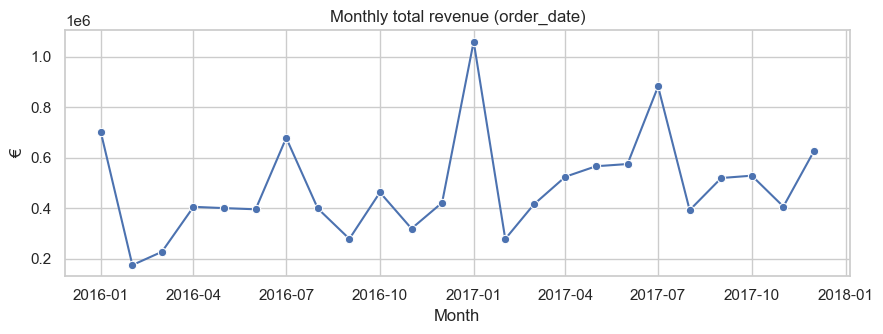

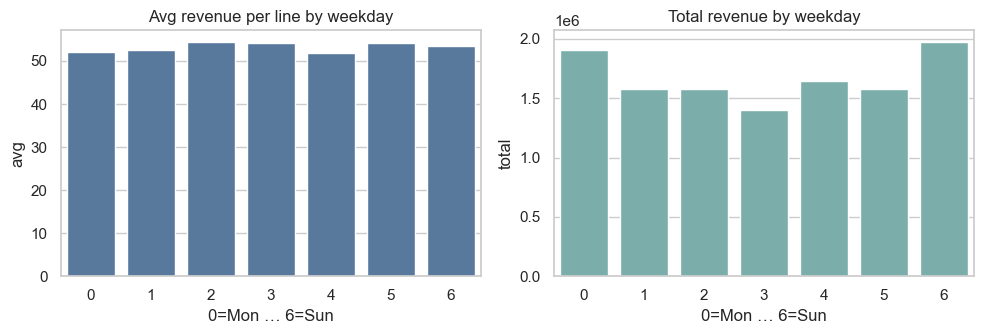

Weekday effect (order_date): H=160.23, p=5.31e-32


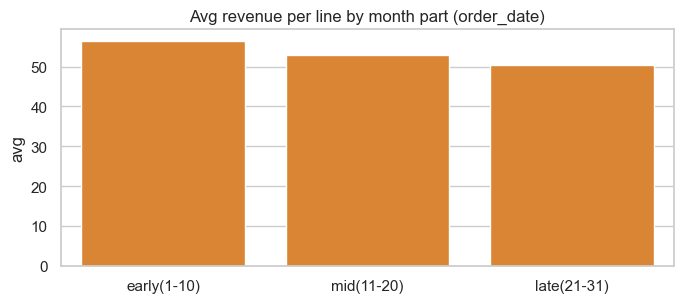

Part-of-month effect (order_date): H=1048.21, p=2.43e-228

Pay-window vs other (order_date) — item level


,rows,total,avg,median,sd
grp,,,,,
pay-window,216,12906.07,59.750324,59.35,39.541064
other,218912,11633928.39,53.144315,53.00,38.116585


Pay-window (order_date) test: U=25929722.0, p=0.0136 | Δmean=6.61, Δmedian=6.35

================ ITEM-LEVEL via pack_date ================



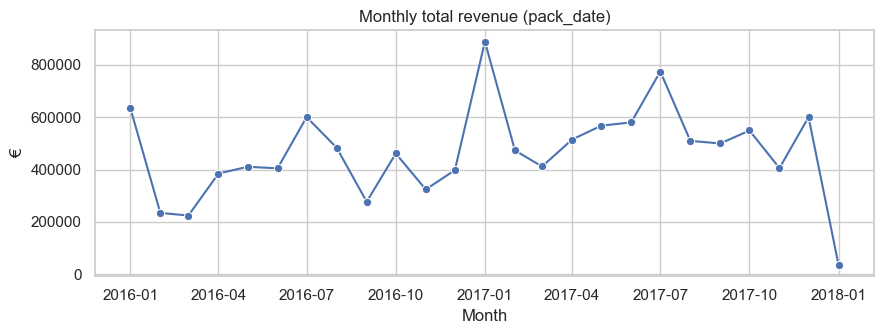

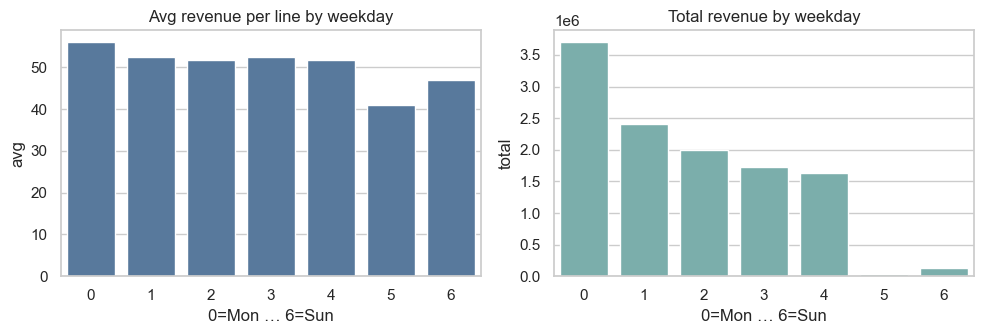

Weekday effect (pack_date): H=665.98, p=1.35e-140


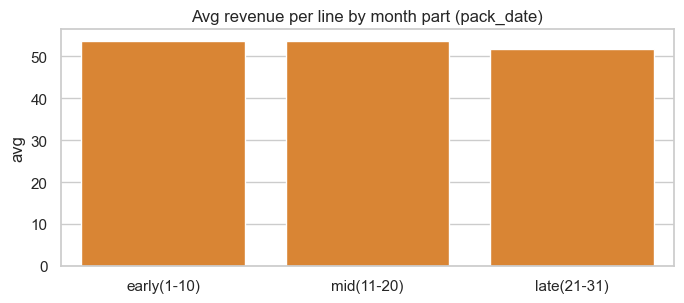

Part-of-month effect (pack_date): H=140.10, p=3.79e-31

Pay-window vs other (pack_date) — item level


,rows,total,avg,median,sd
grp,,,,,
pay-window,225,13660.12,60.711644,59.95,37.971526
other,218903,11633174.34,53.143056,53.00,38.117951


Pay-window (pack_date) test: U=27540234.5, p=0.00206 | Δmean=7.57, Δmedian=6.95

========== ITEM-LEVEL WEEK-OF-MONTH HEATMAP (order_date) ==========



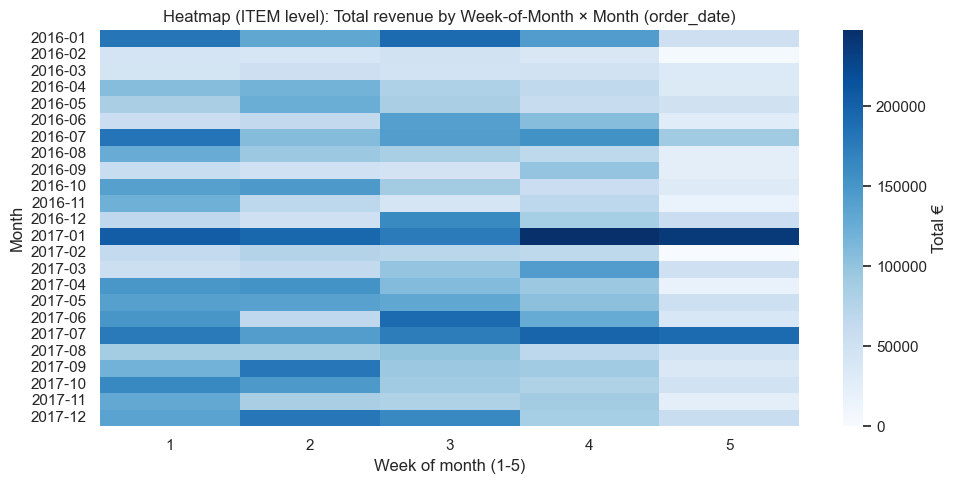


========== ITEM-LEVEL WEEK-OF-MONTH HEATMAP (pack_date) ==========



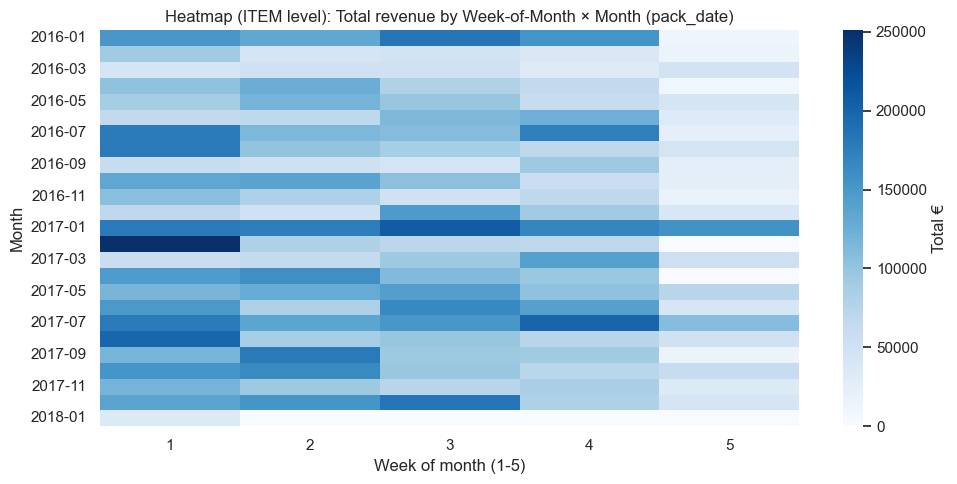

In [33]:
for dc in ["order_date", "pack_date"]:
    if f"{dc}_ym_d" not in df.columns:  # ensure Step 0 ran
        continue
    print(f"\n================ ITEM-LEVEL via {dc} ================\n")

    # ---------- Monthly total revenue ----------
    mon = (df.dropna(subset=[dc])
             .groupby(f"{dc}_ym_d", observed=True)["revenue"].sum().reset_index())
    plt.figure(figsize=(9,3.5))
    sns.lineplot(data=mon, x=f"{dc}_ym_d", y="revenue", marker="o")
    plt.title(f"Monthly total revenue ({dc})"); plt.xlabel("Month"); plt.ylabel("€")
    plt.tight_layout(); plt.show()

    # ---------- Weekday (0=Mon..6=Sun): avg per line & total ----------
    dow = (df.dropna(subset=[dc])
             .groupby(f"{dc}_dow", observed=True)["revenue"]
             .agg(avg="mean", total="sum", rows="size").reset_index())
    fig, ax = plt.subplots(1,2, figsize=(10,3.5))
    sns.barplot(data=dow, x=f"{dc}_dow", y="avg",   ax=ax[0], color="#4C78A8")
    ax[0].set_title("Avg revenue per line by weekday"); ax[0].set_xlabel("0=Mon … 6=Sun")
    sns.barplot(data=dow, x=f"{dc}_dow", y="total", ax=ax[1], color="#72B7B2")
    ax[1].set_title("Total revenue by weekday");       ax[1].set_xlabel("0=Mon … 6=Sun")
    plt.tight_layout(); plt.show()

    # Significance across weekdays (Kruskal–Wallis; item-level)
    wk_groups = [df.loc[(df[f"{dc}_dow"]==d) & df[dc].notna(), "revenue"].dropna().values
                 for d in range(7) if ((df[f"{dc}_dow"]==d) & df[dc].notna()).sum() >= 2]
    if len(wk_groups) >= 2:
        H, p = stats.kruskal(*wk_groups)
        print(f"Weekday effect ({dc}): H={H:.2f}, p={p:.3g}")

    # ---------- Part of month (early/mid/late) ----------
    part = (df.dropna(subset=[dc])
              .groupby(f"{dc}_part", observed=True)["revenue"]
              .agg(avg="mean", total="sum", rows="size").reset_index())
    plt.figure(figsize=(7,3.2))
    sns.barplot(data=part, x=f"{dc}_part", y="avg", color="#F58518")
    plt.title(f"Avg revenue per line by month part ({dc})"); plt.xlabel(""); plt.tight_layout(); plt.show()

    # Test part-of-month (Kruskal-Wallis across 3 buckets if each has ≥2 rows)
    labels = ["early(1-10)","mid(11-20)","late(21-31)"]
    po = [df.loc[(df[f"{dc}_part"]==lab) & df[dc].notna(), "revenue"].dropna().values for lab in labels]
    if all(len(g) >= 2 for g in po):
        H, p = stats.kruskal(*po); print(f"Part-of-month effect ({dc}): H={H:.2f}, p={p:.3g}")

    # ---------- Pay-window (Belgium) vs other ----------
    grp = df.loc[df[dc].notna(), f"{dc}_paywindow_BE"].map({True:"pay-window", False:"other"})
    s = pd.DataFrame({"grp": grp, "rev": df.loc[df[dc].notna(), "revenue"]}).dropna(subset=["grp"])
    tbl = (s.groupby("grp", observed=True)["rev"]
             .agg(rows="size", total="sum", avg="mean", median="median", sd="std")
             .sort_values("avg", ascending=False))
    print(f"\nPay-window vs other ({dc}) — item level"); display(tbl)

    # Mann-Whitney (require ≥2 rows in each)
    if (s["grp"]=="pay-window").sum() >= 2 and (s["grp"]=="other").sum() >= 2:
        a = s.loc[s["grp"]=="pay-window", "rev"].to_numpy()
        b = s.loc[s["grp"]=="other",      "rev"].to_numpy()
        u, p = stats.mannwhitneyu(a, b, alternative="two-sided")
        print(f"Pay-window ({dc}) test: U={u:.1f}, p={p:.3g} | Δmean={a.mean()-b.mean():.2f}, Δmedian={np.median(a)-np.median(b):.2f}")

    # ---------- Month x Weekday heatmap (total €) ----------
    
def week_of_month(dom):
    """Convert day-of-month to week number (1-5)."""
    return ((dom - 1) // 7) + 1

for dc in ["order_date", "pack_date"]:
    if f"{dc}_ym_d" not in df.columns:
        continue

    # Week of month (1-5)
    df[f"{dc}_wom"] = week_of_month(df[f"{dc}_dom"])

    print(f"\n========== ITEM-LEVEL WEEK-OF-MONTH HEATMAP ({dc}) ==========\n")

    # Total revenue per (month, week_of_month)
    hm_item = (
        df.dropna(subset=[dc])
          .groupby([f"{dc}_ym", f"{dc}_wom"], observed=True)["revenue"]
          .sum()
          .unstack(fill_value=0)
    )

    # Ensure sorted by month
    hm_item = hm_item.loc[sorted(hm_item.index)]

    plt.figure(figsize=(10,5))
    sns.heatmap(hm_item, cmap="Blues", cbar_kws={"label": "Total €"})
    plt.title(f"Heatmap (ITEM level): Total revenue by Week-of-Month × Month ({dc})")
    plt.xlabel("Week of month (1-5)")
    plt.ylabel("Month")
    plt.tight_layout()
    plt.show()

### Costumer level

Interpretation
* clear patterns across months with dips in summer
* in pay window: different patterns than when looking at per item, spend more outside of pay window


================ CUSTOMER-LEVEL via order_date ================



/var/folders/hf/7q1165696l3cv3h97wcgcjxh0000gn/T/ipykernel_1150/2505353827.py:32: UserWarning: Glyph 8209 (\N{NON-BREAKING HYPHEN}) missing from font(s) Arial.
  plt.xlabel("Month"); plt.ylabel("€"); plt.legend(); plt.tight_layout()
/Users/chloe/Library/Python/3.12/lib/python/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8209 (\N{NON-BREAKING HYPHEN}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


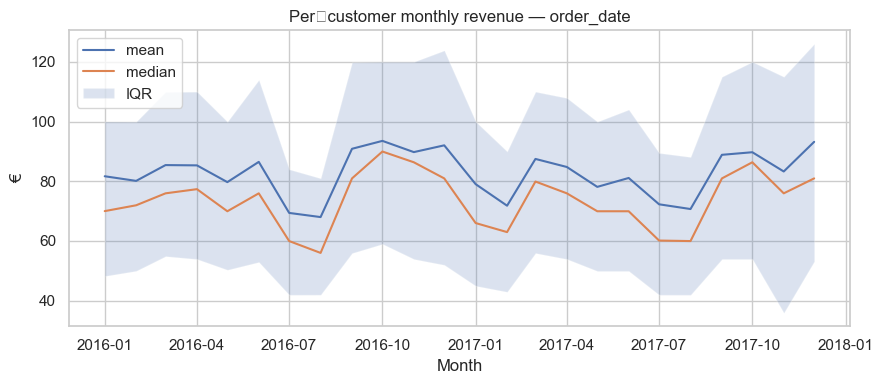

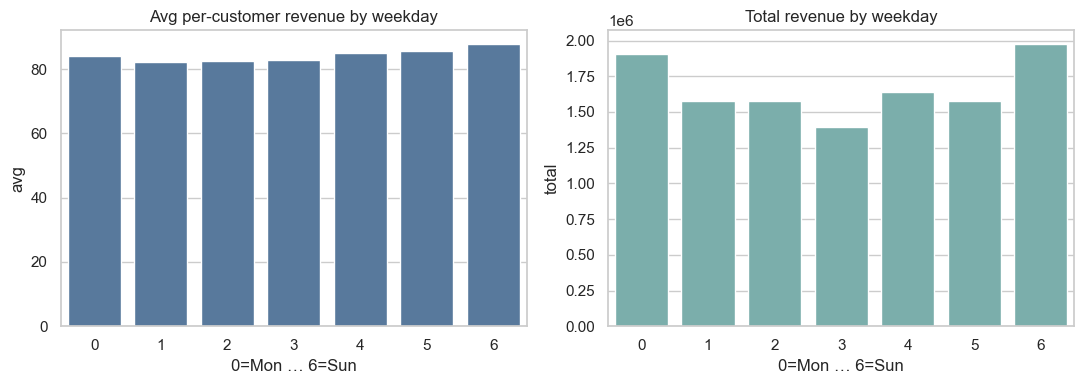

Customer-level weekday effect (order_date) — Friedman χ²=1.82, p=0.936


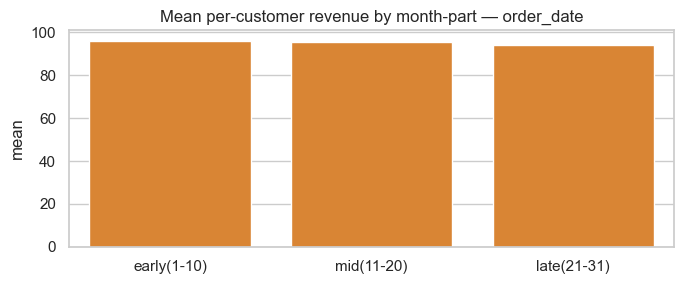

Part-of-month effect (order_date) — Friedman χ²=0.65, p=0.721

Pay-window vs other — per-customer totals (order_date)


,rows,total,avg,median,sd
order_date_paywindow_BE,,,,,
other,93199,11633928.39,124.828897,89.850,118.053770
pay-window,188,12906.07,68.649309,62.725,47.076562


Wilcoxon (pay-window vs other): W=851.0, p=6.85e-12 | Δmean=-125.21, Δmedian=-66.65 (n=115)

================ CUSTOMER-LEVEL via pack_date ================



/var/folders/hf/7q1165696l3cv3h97wcgcjxh0000gn/T/ipykernel_1150/2505353827.py:32: UserWarning: Glyph 8209 (\N{NON-BREAKING HYPHEN}) missing from font(s) Arial.
  plt.xlabel("Month"); plt.ylabel("€"); plt.legend(); plt.tight_layout()
/Users/chloe/Library/Python/3.12/lib/python/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8209 (\N{NON-BREAKING HYPHEN}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


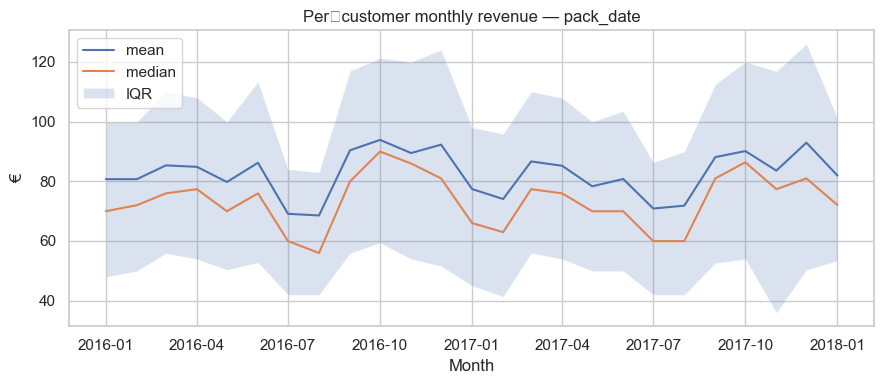

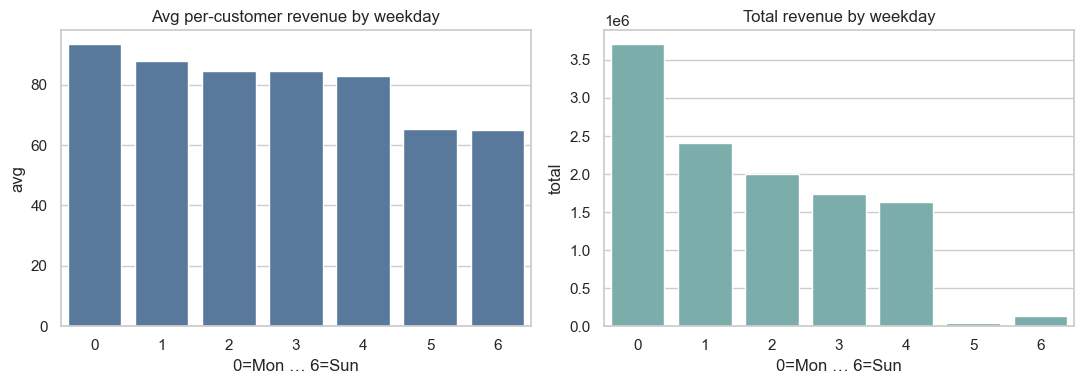

Weekday test (pack_date): not enough customers with all 7 weekdays.


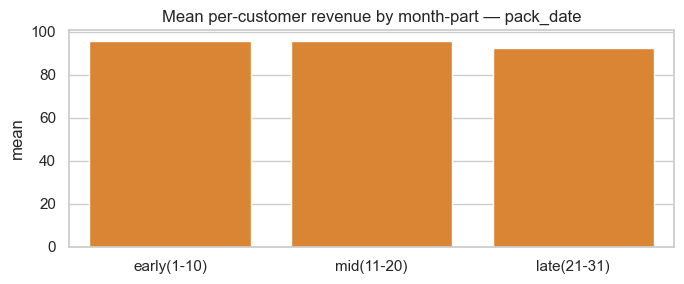

Part-of-month effect (pack_date) — Friedman χ²=10.07, p=0.0065

Pay-window vs other — per-customer totals (pack_date)


,rows,total,avg,median,sd
pack_date_paywindow_BE,,,,,
other,93219,11633174.34,124.794026,89.72,117.989418
pay-window,187,13660.12,73.048770,62.95,51.793086


Wilcoxon (pay-window vs other): W=1458.0, p=7.76e-11 | Δmean=-145.45, Δmedian=-56.17 (n=134)

========== CUSTOMER-LEVEL WEEK-OF-MONTH HEATMAP (order_date) ==========



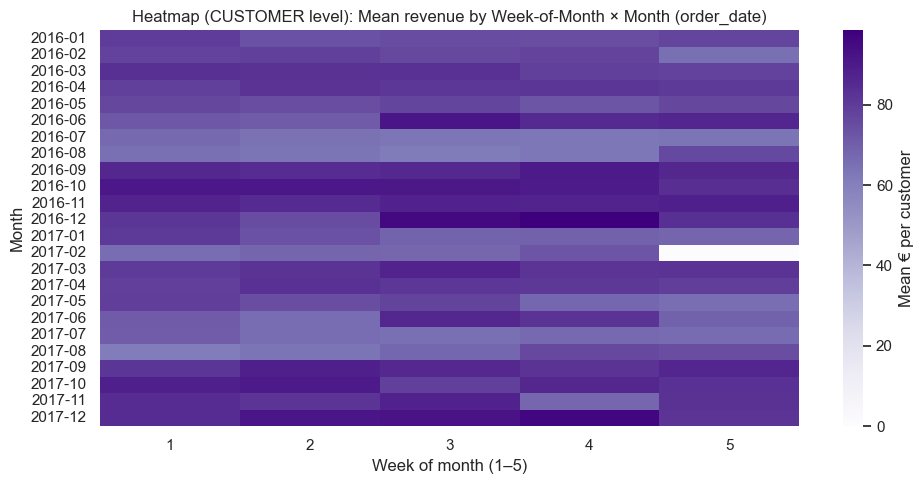


========== CUSTOMER-LEVEL WEEK-OF-MONTH HEATMAP (pack_date) ==========



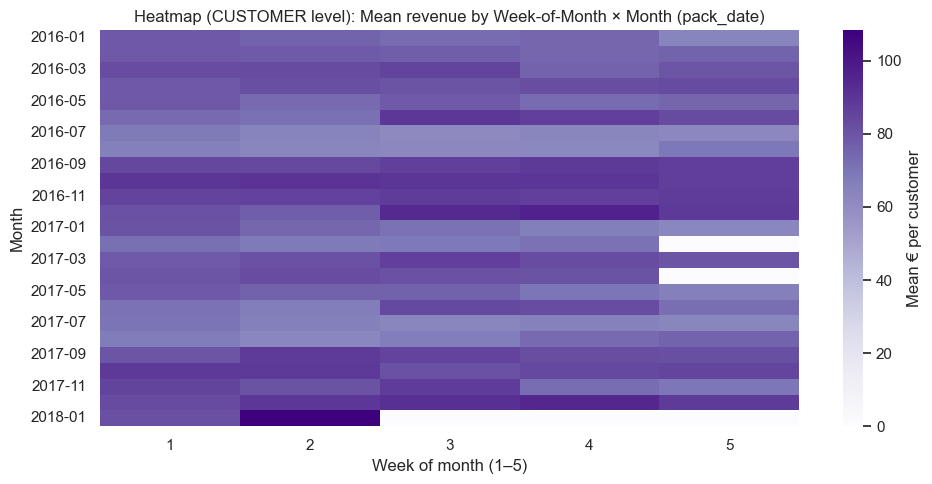

In [34]:
cust = "cust_id" if "cust_id" in df.columns else "customer_id"

for dc in ["order_date", "pack_date"]:
    if f"{dc}_ym_d" not in df.columns:
        continue

    print(f"\n================ CUSTOMER-LEVEL via {dc} ================\n")

    # ------------------------------------------------------
    # 1) MONTHLY TREND per customer
    # ------------------------------------------------------
    cm = (
        df.dropna(subset=[dc])
          .groupby([cust, f"{dc}_ym_d"], observed=True)["revenue"]
          .sum()
          .reset_index(name="rev")
    )

    monthly = (
        cm.groupby(f"{dc}_ym_d", observed=True)["rev"]
          .agg(mean="mean", median="median",
               q25=lambda s: s.quantile(.25), q75=lambda s: s.quantile(.75))
          .reset_index()
    )

    plt.figure(figsize=(9,4))
    sns.lineplot(data=monthly, x=f"{dc}_ym_d", y="mean", label="mean")
    sns.lineplot(data=monthly, x=f"{dc}_ym_d", y="median", label="median")
    plt.fill_between(monthly[f"{dc}_ym_d"], monthly["q25"], monthly["q75"],
                     alpha=.2, label="IQR")
    plt.title(f"Per‑customer monthly revenue — {dc}")
    plt.xlabel("Month"); plt.ylabel("€"); plt.legend(); plt.tight_layout()
    plt.show()

    # ------------------------------------------------------
    # 2) WEEKDAY — per customer (avg + total) + heatmap
    # ------------------------------------------------------
    cdow = (
        df.dropna(subset=[dc])
          .groupby([cust, f"{dc}_dow"], observed=True)["revenue"]
          .sum()
          .reset_index()
    )

    weekday_avg = (
        cdow.groupby(f"{dc}_dow", observed=True)["revenue"]
            .agg(avg="mean", median="median", customers="size")
            .reset_index()
    )

    weekday_tot = (
        df.dropna(subset=[dc])
            .groupby(f"{dc}_dow", observed=True)["revenue"]
            .sum()
            .reset_index(name="total")
    )

    fig, ax = plt.subplots(1,2, figsize=(11,4))
    sns.barplot(data=weekday_avg, x=f"{dc}_dow", y="avg",
                ax=ax[0], color="#4C78A8")
    ax[0].set_title("Avg per-customer revenue by weekday")
    ax[0].set_xlabel("0=Mon … 6=Sun")

    sns.barplot(data=weekday_tot, x=f"{dc}_dow", y="total",
                ax=ax[1], color="#72B7B2")
    ax[1].set_title("Total revenue by weekday")
    ax[1].set_xlabel("0=Mon … 6=Sun")

    plt.tight_layout()
    plt.show()

    # — Friedman test across weekdays (within-customer repeated measures) —
    pvt = cdow.pivot_table(index=cust, columns=f"{dc}_dow",
                           values="revenue", aggfunc="sum").dropna()
    if pvt.shape[0] >= 5:
        W, p = stats.friedmanchisquare(*[pvt[col].values for col in sorted(pvt.columns)])
        print(f"Customer-level weekday effect ({dc}) — Friedman χ²={W:.2f}, p={p:.3g}")
    else:
        print(f"Weekday test ({dc}): not enough customers with all 7 weekdays.")

    # ------------------------------------------------------
    # 3) DAY‑OF‑MONTH buckets (early/mid/late)
    # ------------------------------------------------------
    cpart = (
        df.dropna(subset=[dc])
          .groupby([cust, f"{dc}_part"], observed=True)["revenue"]
          .sum()
          .reset_index()
    )

    part_tbl = (
        cpart.groupby(f"{dc}_part", observed=True)["revenue"]
             .agg(mean="mean", median="median")
             .reset_index()
    )

    plt.figure(figsize=(7,3))
    sns.barplot(data=part_tbl, x=f"{dc}_part", y="mean", color="#F58518")
    plt.title(f"Mean per-customer revenue by month-part — {dc}")
    plt.xlabel(""); plt.tight_layout(); plt.show()

    # — Friedman test early/mid/late —
    part_pvt = (
        cpart.pivot_table(index=cust, columns=f"{dc}_part",
                          values="revenue", aggfunc="sum")
             .reindex(columns=["early(1-10)","mid(11-20)","late(21-31)"])
             .dropna()
    )
    if part_pvt.shape[0] >= 5:
        W, p = stats.friedmanchisquare(*[part_pvt[col].values for col in part_pvt.columns])
        print(f"Part-of-month effect ({dc}) — Friedman χ²={W:.2f}, p={p:.3g}")
    else:
        print(f"Part-of-month test ({dc}): not enough complete customers.")

    # ------------------------------------------------------
    # 4) Belgian PAY‑WINDOW vs OTHER (paired)
    # ------------------------------------------------------
    cpw = (
        df.dropna(subset=[dc])
          .groupby([cust, f"{dc}_paywindow_BE"], observed=True)["revenue"]
          .sum()
          .reset_index()
    )

    # Summary table
    tbl_pw = (
        cpw.replace({f"{dc}_paywindow_BE": {True:"pay-window", False:"other"}})
           .groupby(f"{dc}_paywindow_BE")["revenue"]
           .agg(rows="size", total="sum", avg="mean", median="median", sd="std")
    )
    print(f"\nPay-window vs other — per-customer totals ({dc})")
    display(tbl_pw)

    # Wilcoxon signed‑rank (paired)
    pvt_pw = cpw.pivot_table(index=cust, columns=f"{dc}_paywindow_BE",
                             values="revenue", aggfunc="sum")
    if {True, False}.issubset(pvt_pw.columns):
        paired = pvt_pw.dropna()
        if paired.shape[0] >= 5:
            w, p = stats.wilcoxon(paired[True], paired[False])
            d_mean   = float((paired[True] - paired[False]).mean())
            d_median = float(np.median(paired[True] - paired[False]))
            print(f"Wilcoxon (pay-window vs other): W={w:.1f}, p={p:.3g} "
                  f"| Δmean={d_mean:.2f}, Δmedian={d_median:.2f} "
                  f"(n={paired.shape[0]})")
        else:
            print("Pay-window test: not enough paired customers.")
    else:
        print("Pay-window test: missing one of the categories.")


def week_of_month(dom):
    return ((dom - 1) // 7) + 1

for dc in ["order_date", "pack_date"]:
    if f"{dc}_ym_d" not in df.columns:
        continue

    print(f"\n========== CUSTOMER-LEVEL WEEK-OF-MONTH HEATMAP ({dc}) ==========\n")

    df[f"{dc}_wom"] = week_of_month(df[f"{dc}_dom"])

    # Per (customer, month, week) revenue
    base = (
        df.dropna(subset=[dc])
          .groupby([cust, f"{dc}_ym", f"{dc}_wom"], observed=True)["revenue"]
          .sum()
          .reset_index()
    )

    # Mean per-customer revenue for each month × week
    hm_cust = (
        base.groupby([f"{dc}_ym", f"{dc}_wom"], observed=True)["revenue"]
            .mean()
            .unstack(fill_value=0)
    )

    hm_cust = hm_cust.loc[sorted(hm_cust.index)]

    plt.figure(figsize=(10,5))
    sns.heatmap(hm_cust, cmap="Purples", cbar_kws={"label": "Mean € per customer"})
    plt.title(f"Heatmap (CUSTOMER level): Mean revenue by Week-of-Month × Month ({dc})")
    plt.xlabel("Week of month (1–5)")
    plt.ylabel("Month")
    plt.tight_layout()
    plt.show()


# Exploring other relations between variables

## Correlations between if_known variables

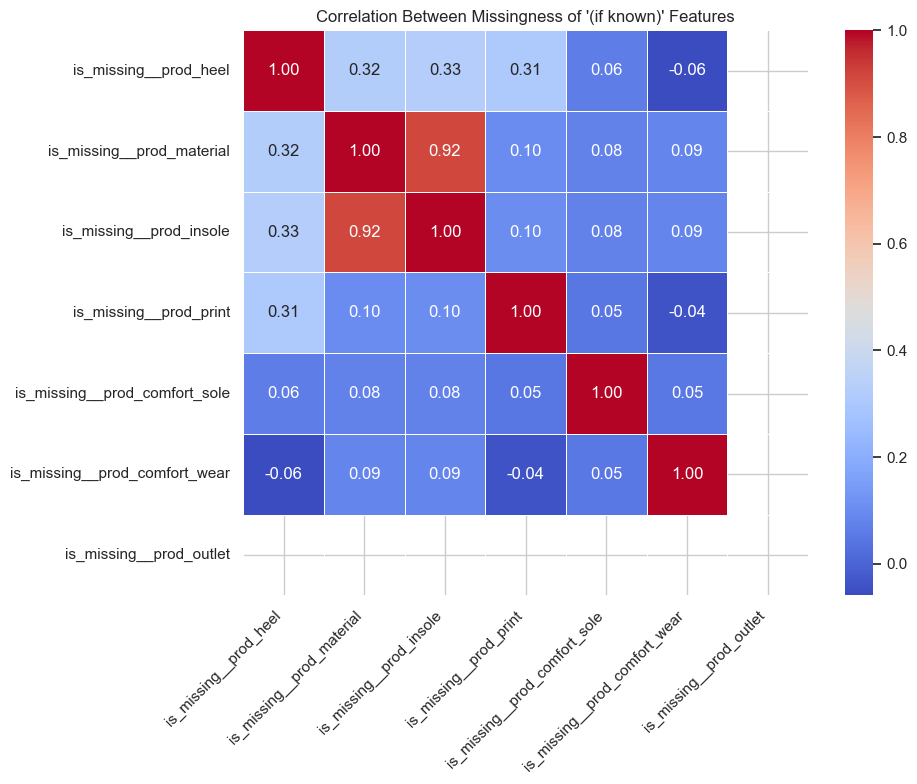

In [38]:
# -----------------------------------------------------------
# 1. LIST OF FEATURES THAT HAVE "(if known)"
# -----------------------------------------------------------
if_known_features = [
    "prod_heel",         # (if known)
    "prod_material",     
    "prod_insole",       
    "prod_print",        
    "prod_comfort_sole",
    "prod_comfort_wear",
    "prod_fastening",
    "prod_outlet"
]

# keep only those actually present in your dataset
if_known_features = [c for c in if_known_features if c in df.columns]

# -----------------------------------------------------------
# 2. CREATE MISSINGNESS INDICATORS
# -----------------------------------------------------------
missing_indicators = {}

for col in if_known_features:
    miss_col = f"is_missing__{col}"
    df[miss_col] = df[col].isna().astype(int)
    missing_indicators[col] = miss_col

missing_df = df[list(missing_indicators.values())]

# -----------------------------------------------------------
# 3. COMPUTE CORRELATION MATRIX
# -----------------------------------------------------------
corr_matrix = missing_df.corr()

# -----------------------------------------------------------
# 4. PLOT HEATMAP
# -----------------------------------------------------------
plt.figure(figsize=(10, 8))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5,
    square=True
)

plt.title("Correlation Between Missingness of '(if known)' Features")
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

## Season and time


================ SEASON × TIME — using order_date ================



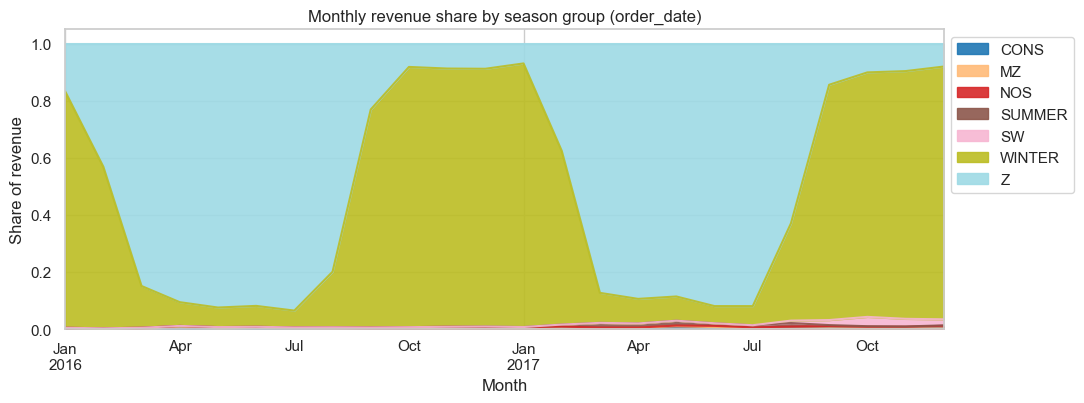

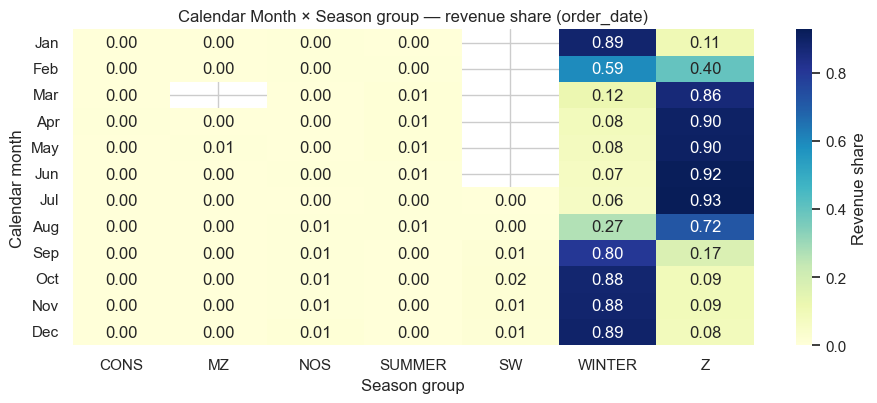

Chi-square (Month × Season group) on row counts (order_date): χ²=137314.2, dof=66, p=0


/var/folders/hf/7q1165696l3cv3h97wcgcjxh0000gn/T/ipykernel_1150/1066689257.py:145: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', 95)` for the same effect.

  ax = sns.barplot(data=d, x="season_group", y="revenue", estimator=np.mean, ci=95, color="#4C78A8")


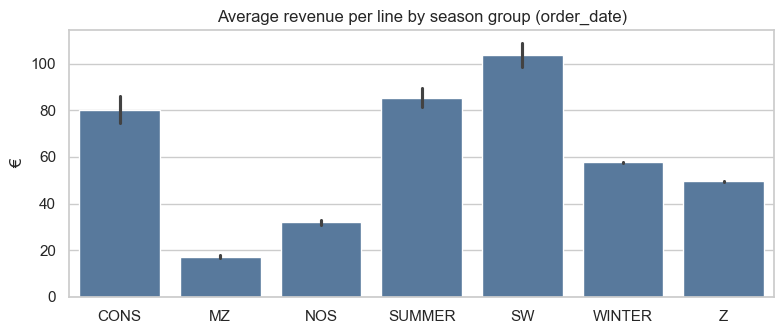

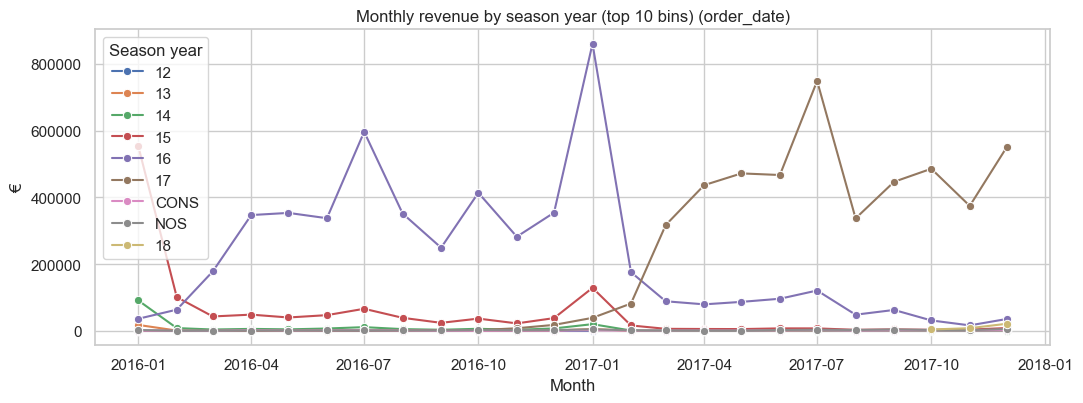

/var/folders/hf/7q1165696l3cv3h97wcgcjxh0000gn/T/ipykernel_1150/1066689257.py:190: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  sns.violinplot(data=d, x="season_group", y="age_years", inner="quartile", scale="width")


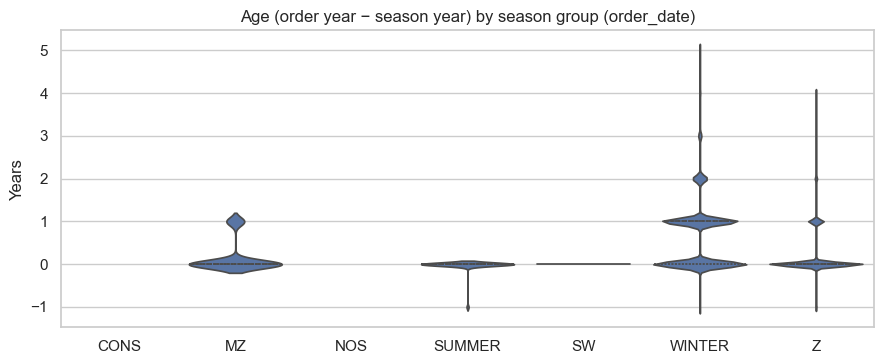

Kruskal–Wallis on age across season groups (order_date): H=30868.24, p=0

================ SEASON × TIME — using pack_date ================



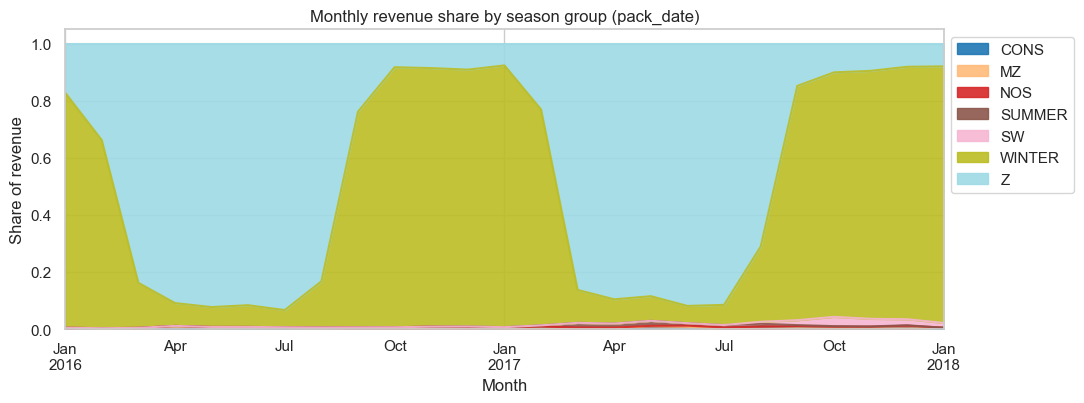

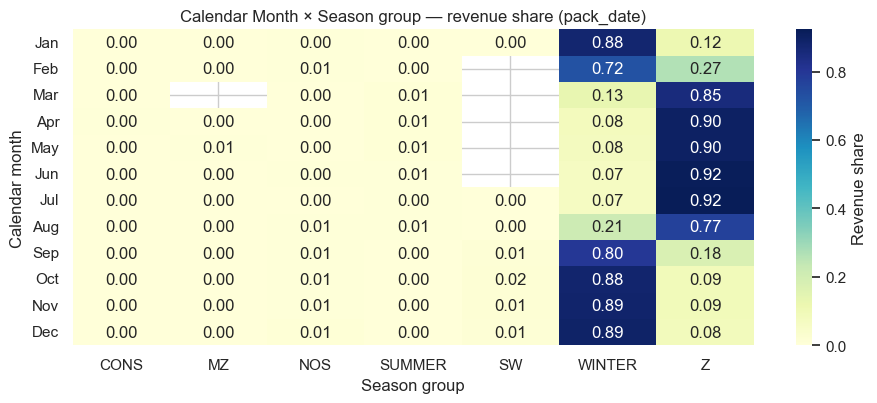

Chi-square (Month × Season group) on row counts (pack_date): χ²=135348.2, dof=66, p=0


/var/folders/hf/7q1165696l3cv3h97wcgcjxh0000gn/T/ipykernel_1150/1066689257.py:145: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', 95)` for the same effect.

  ax = sns.barplot(data=d, x="season_group", y="revenue", estimator=np.mean, ci=95, color="#4C78A8")


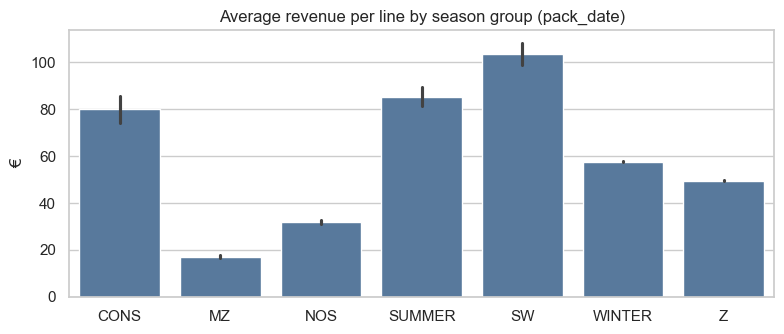

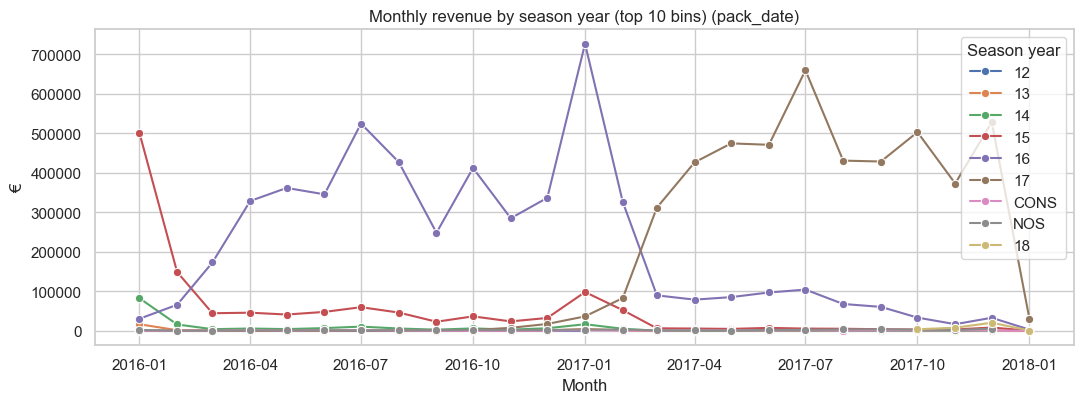

/var/folders/hf/7q1165696l3cv3h97wcgcjxh0000gn/T/ipykernel_1150/1066689257.py:190: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  sns.violinplot(data=d, x="season_group", y="age_years", inner="quartile", scale="width")


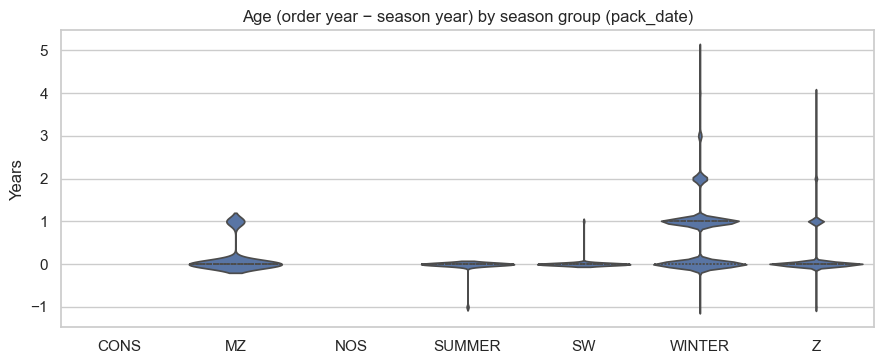

Kruskal–Wallis on age across season groups (pack_date): H=32033.43, p=0


In [40]:
import scipy.stats as stats
from scipy.stats import chi2_contingency

sns.set(style="whitegrid")

# =========================================================
# 0) SAFETY: ensure the needed date parts exist
# =========================================================
def ensure_date_parts(df, dc):
    if df[dc].dtype.kind in "mM":  # datetime64
        if f"{dc}_y" not in df.columns:
            df[f"{dc}_y"]  = df[dc].dt.year
        if f"{dc}_m" not in df.columns:
            df[f"{dc}_m"]  = df[dc].dt.month
        if f"{dc}_ym" not in df.columns:
            # monthly period as ordered category string, e.g., '2018-07'
            df[f"{dc}_ym"] = df[dc].dt.to_period("M").astype(str)
        if f"{dc}_dow" not in df.columns:
            df[f"{dc}_dow"] = df[dc].dt.dayofweek
        if f"{dc}_dom" not in df.columns:
            df[f"{dc}_dom"] = df[dc].dt.day

for dc in ["order_date", "pack_date"]:
    if dc in df.columns:
        ensure_date_parts(df, dc)

# =========================================================
# 1) Normalize prod_season → season_letters, season_year_cat (+ helpers)
#    Examples: 'W14', 'S17', 'MW19', 'SZ18', 'NOS', 'CONS', 'W 2016'
# =========================================================
_s = df["prod_season"].astype("string").str.strip().str.upper()

df["season_letters"] = _s.str.extract(r'^([A-Z]+)')[0]
_last_num = _s.str.extract(r'(\d{2,4})$')[0]  # '16' or '2016'

# season_year_cat keeps NOS/CONS; otherwise the trailing number, else 'Unknown'
df["season_year_cat"] = np.where(
    df["season_letters"].isin(["NOS", "CONS"]),
    df["season_letters"],
    _last_num
)
df["season_year_cat"] = df["season_year_cat"].fillna("Unknown").astype("category")

# Optional: numeric season year (two or four-digit → four-digit)
def to_four_digit_year(x):
    if pd.isna(x): return np.nan
    s = str(x)
    if s.isdigit():
        num = int(s)
        if   0 <= num < 30:  return 2000 + num   # 00–29 → 2000–2029 (adjust to your context)
        if  30 <= num < 100: return 1900 + num   # 30–99 → 1930–1999 (or tweak)
        if 1000 <= num <= 2100: return num
    return np.nan

df["season_year_num"] = df["season_year_cat"].apply(to_four_digit_year)

# Season groups (keep non-mapped prefixes as-is)
season_map = {
    # winter-like
    "W":"WINTER", "FW":"WINTER", "AW":"WINTER", "MW":"WINTER", "ZW":"WINTER",
    # summer-like
    "S":"SUMMER", "SS":"SUMMER", "SZ":"SUMMER", "SP":"SUMMER",
    # perpetual lines
    "NOS":"NOS", "CONS":"CONS"
}
df["season_group"] = df["season_letters"].map(season_map).fillna(df["season_letters"])
df["season_group"] = df["season_group"].fillna("Unknown").astype("category")

# Nice month labels (ordered)
month_labels = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]

# =========================================================
# 2) PLOTTERS
# =========================================================
def plot_stacked_area_share(df, dc):
    # Monthly revenue share by season_group
    d = (df.dropna(subset=[dc])
           .groupby([f"{dc}_ym", "season_group"], observed=True)["revenue"]
           .sum()
           .reset_index())
    if d.empty:
        print(f"[{dc}] No data for stacked area.")
        return

    # ensure chronological order on x
    d["_ym_ord"] = pd.to_datetime(d[f"{dc}_ym"], format="%Y-%m")
    # total per month
    tot = d.groupby("_ym_ord")["revenue"].transform("sum")
    d["share"] = d["revenue"] / tot

    # pivot to wide for stacked area
    wide = d.pivot_table(index="_ym_ord", columns="season_group", values="share", fill_value=0)
    wide = wide.sort_index()

    ax = wide.plot.area(figsize=(11,4.2), alpha=0.9, colormap="tab20")
    ax.set_title(f"Monthly revenue share by season group ({dc})")
    ax.set_ylabel("Share of revenue")
    ax.set_xlabel("Month")
    ax.legend(loc="upper left", bbox_to_anchor=(1,1))
    plt.tight_layout()
    plt.show()

def plot_month_vs_season_heatmap(df, dc):
    # Calendar month × season_group (share of revenue)
    d = df.dropna(subset=[dc]).copy()
    d[f"{dc}_m"] = d[f"{dc}_m"].astype(int)
    # aggregate revenue
    g = (d.groupby([f"{dc}_m", "season_group"], observed=True)["revenue"]
           .sum()
           .reset_index())

    if g.empty:
        print(f"[{dc}] No data for month × season heatmap.")
        return

    # row-normalize to get shares within each calendar month
    total_by_month = g.groupby(f"{dc}_m")["revenue"].transform("sum")
    g["share"] = g["revenue"] / total_by_month

    hm = g.pivot(index=f"{dc}_m", columns="season_group", values="share").reindex(range(1,13))
    hm.index = [month_labels[i-1] for i in hm.index]

    plt.figure(figsize=(9.5,4.2))
    sns.heatmap(hm, cmap="YlGnBu", annot=True, fmt=".2f", cbar_kws={"label":"Revenue share"})
    plt.title(f"Calendar Month × Season group — revenue share ({dc})")
    plt.xlabel("Season group"); plt.ylabel("Calendar month")
    plt.tight_layout(); plt.show()

    # Chi-square test: month vs season_group using counts (rows = month, cols = season_group)
    # You can switch to revenue weights by discretizing or using a test on proportions.
    counts = (df.dropna(subset=[dc])
                .groupby([f"{dc}_m", "season_group"], observed=True)["revenue"]
                .size()
                .unstack(fill_value=0))
    if counts.shape[0] >= 2 and counts.shape[1] >= 2:
        chi2, p, dof, _ = chi2_contingency(counts)
        print(f"Chi-square (Month × Season group) on row counts ({dc}): χ²={chi2:.1f}, dof={dof}, p={p:.3g}")

def plot_avg_rev_by_season(df, dc):
    d = df.dropna(subset=[dc]).copy()
    if d.empty:
        print(f"[{dc}] No data for avg revenue per line.")
        return
    plt.figure(figsize=(8,3.5))
    ax = sns.barplot(data=d, x="season_group", y="revenue", estimator=np.mean, ci=95, color="#4C78A8")
    ax.set_title(f"Average revenue per line by season group ({dc})")
    ax.set_xlabel(""); ax.set_ylabel("€")
    plt.tight_layout(); plt.show()

def plot_season_year_trend(df, dc):
    # Monthly revenue by season_year_cat (top N, others grouped)
    d = (df.dropna(subset=[dc])
           .groupby([f"{dc}_ym", "season_year_cat"], observed=True)["revenue"]
           .sum()
           .reset_index())
    if d.empty:
        print(f"[{dc}] No data for season_year monthly trend.")
        return

    d["_ym_ord"] = pd.to_datetime(d[f"{dc}_ym"], format="%Y-%m")
    # Keep top 10 season_year_cat by total revenue
    top = (d.groupby("season_year_cat")["revenue"].sum()
             .sort_values(ascending=False).head(10).index)
    d["season_year_cat_top"] = np.where(d["season_year_cat"].isin(top), d["season_year_cat"], "Other")

    plt.figure(figsize=(11,4.2))
    sns.lineplot(data=d, x="_ym_ord", y="revenue", hue="season_year_cat_top", marker="o")
    plt.title(f"Monthly revenue by season year (top 10 bins) ({dc})")
    plt.xlabel("Month"); plt.ylabel("€"); plt.legend(title="Season year")
    plt.tight_layout(); plt.show()

def plot_age_vs_time(df, dc):
    """
    Age (in years) = order/pack year - season_year_num.
    Only computed when season_year_num is available (not NOS/CONS/Unknown).
    """
    if "season_year_num" not in df.columns or df["season_year_num"].notna().sum() == 0:
        print("No numeric season year to compute age.")
        return
    d = df.dropna(subset=[dc, "season_year_num"]).copy()
    d["age_years"] = d[f"{dc}_y"] - d["season_year_num"]
    # Optional: trim extreme ages for clearer plot
    d = d[(d["age_years"] >= -1) & (d["age_years"] <= 6)]

    if d.empty:
        print(f"[{dc}] No data for age analysis.")
        return

    plt.figure(figsize=(9,3.8))
    sns.violinplot(data=d, x="season_group", y="age_years", inner="quartile", scale="width")
    plt.title(f"Age (order year − season year) by season group ({dc})")
    plt.xlabel(""); plt.ylabel("Years")
    plt.tight_layout(); plt.show()

    # Test if median age differs across season groups (Kruskal–Wallis)
    groups = [g["age_years"].dropna().values for _, g in d.groupby("season_group") if len(g) >= 2]
    if len(groups) >= 2:
        H, p = stats.kruskal(*groups)
        print(f"Kruskal–Wallis on age across season groups ({dc}): H={H:.2f}, p={p:.3g}")

# =========================================================
# 3) RUN FOR BOTH DATE COLUMNS
# =========================================================
for dc in ["order_date", "pack_date"]:
    if dc not in df.columns:
        continue
    print(f"\n================ SEASON × TIME — using {dc} ================\n")
    plot_stacked_area_share(df, dc)
    plot_month_vs_season_heatmap(df, dc)
    plot_avg_rev_by_season(df, dc)
    plot_season_year_trend(df, dc)
    plot_age_vs_time(df, dc)

Ideas
* shoe size & age, as well as prod_heel

## Shoe size, heel presence and gender

Rows used: 134816

=== Shoe size by age × gender × heel type ===


n  mean_size   sd_size  min_size  max_size
age_cat gender_cat prod_heel                                                
adult   female     2.5-5 cm   20932  38.913243  1.711140      35.0      45.0
                   5-8 cm     22747  38.620785  1.650771      34.0      45.0
                   <2.5 cm    60103  38.922691  1.659672      35.0      45.0
                   >8 cm       4119  38.550012  1.677581      35.0      45.0
child   female     2.5-5 cm      83  36.313253  1.829152      32.0      40.0
                   <2.5 cm    26832  29.499851  5.133340      16.0      42.0

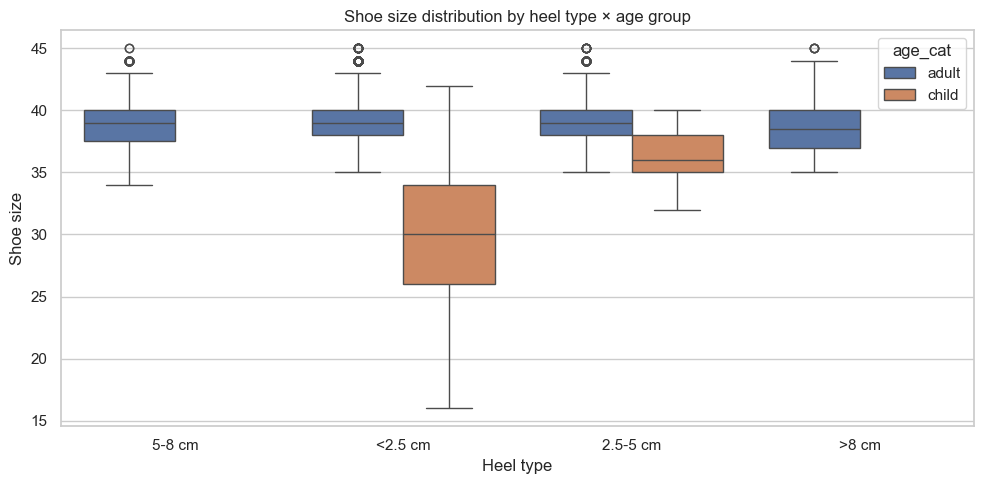

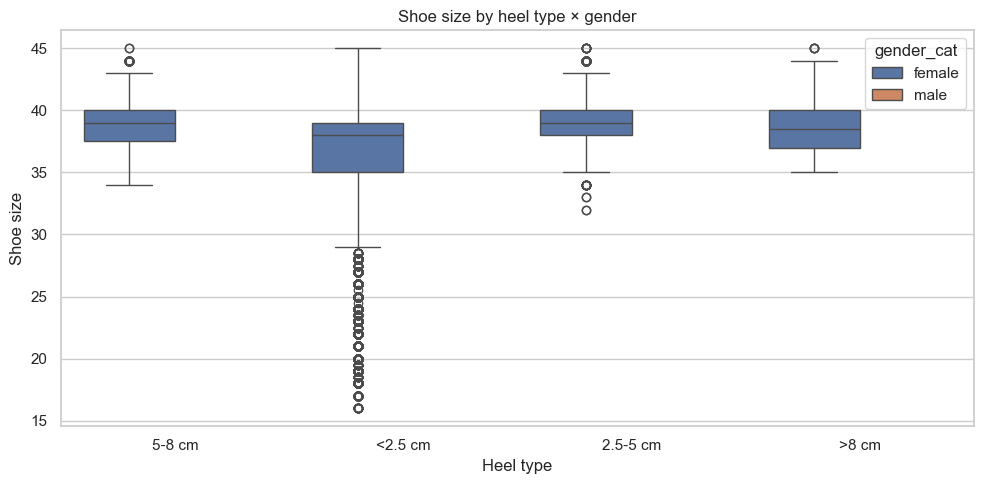

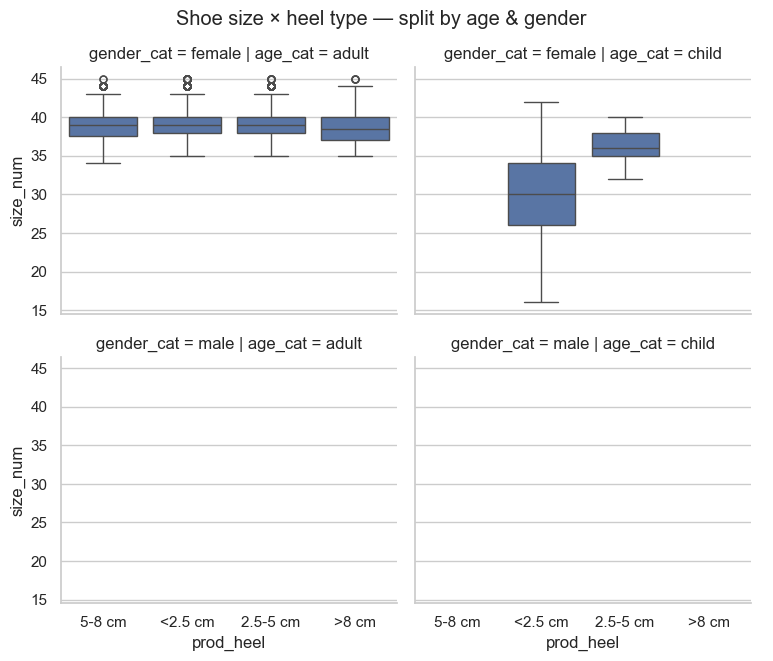

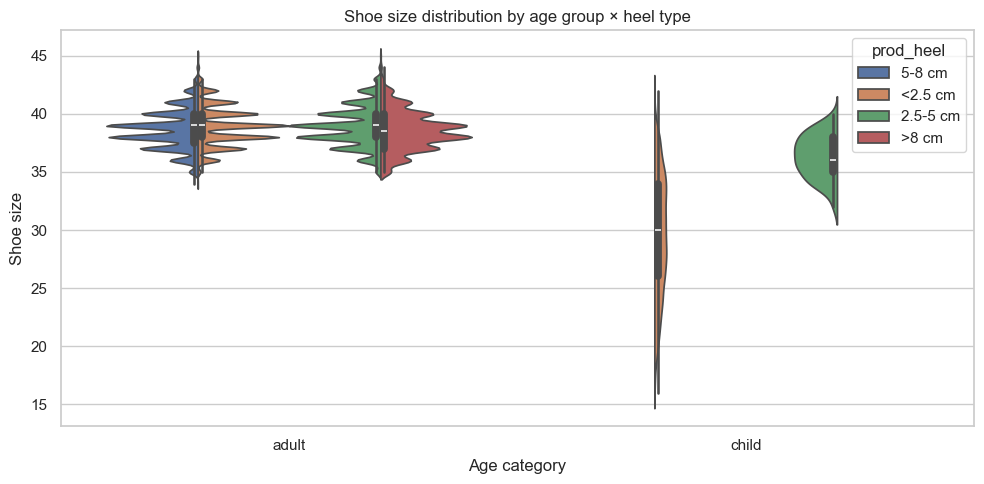


Kruskal–Wallis: SIZE across age groups → H=57841.38, p=0
Kruskal–Wallis: SIZE across heel types → H=5900.05, p=0

Pearson(size, adult=1): r=0.805, p=0
Spearman(size, adult=1): ρ=0.655, p=0


In [ ]:
from scipy.stats import kruskal, pearsonr, spearmanr

sns.set(style="whitegrid")

# ============================================================
# 0) CLEAN DATAFRAME FOR ANALYSIS
# ============================================================
vars_needed = ["size_num", "gender_cat", "age_cat", "prod_heel"]
d = df[vars_needed].copy()

# keep only rows where shoe size + heel type are known
d_clean = d.dropna(subset=["size_num", "prod_heel"])
print("Rows used:", len(d_clean))


# ============================================================
# 1) SUMMARY TABLE
# ============================================================
summary = (
    d_clean.groupby(["age_cat", "gender_cat", "prod_heel"], observed=True)
           .agg(
               n=("size_num", "size"),
               mean_size=("size_num", "mean"),
               sd_size=("size_num", "std"),
               min_size=("size_num", "min"),
               max_size=("size_num", "max")
           )
)

print("\n=== Shoe size by age x gender x heel type ===")
display(summary)


# ============================================================
# 2) VISUALS
# ============================================================

# --- 2A: Boxplot: shoe size by heel type, split by age group ---
plt.figure(figsize=(10,5))
sns.boxplot(
    data=d_clean,
    x="prod_heel", y="size_num",
    hue="age_cat"
)
plt.title("Shoe size distribution by heel type x age group")
plt.xlabel("Heel type"); plt.ylabel("Shoe size")
plt.tight_layout(); plt.show()


# --- 2B: Boxplot: shoe size by heel × gender ---
plt.figure(figsize=(10,5))
sns.boxplot(
    data=d_clean,
    x="prod_heel", y="size_num",
    hue="gender_cat"
)
plt.title("Shoe size by heel type x gender")
plt.xlabel("Heel type"); plt.ylabel("Shoe size")
plt.tight_layout(); plt.show()


# --- 2C: FacetGrid: shoe size distribution by age × gender ---
g = sns.catplot(
    data=d_clean, x="prod_heel", y="size_num",
    col="age_cat", row="gender_cat",
    kind="box", height=3.2, aspect=1.2
)
g.fig.suptitle("Shoe size x heel type — split by age & gender", y=1.03)
plt.show()


# --- 2D: Violin plot for smooth distribution overview ---
plt.figure(figsize=(10,5))
sns.violinplot(
    data=d_clean,
    x="age_cat", y="size_num",
    hue="prod_heel",
    split=True
)
plt.title("Shoe size distribution by age group x heel type")
plt.xlabel("Age category"); plt.ylabel("Shoe size")
plt.tight_layout(); plt.show()


# ============================================================
# 3) STATISTICAL TESTS
# ============================================================

# --- 3A: Do shoe sizes differ across age groups? ---
groups_age = [
    g["size_num"].dropna().values
    for _, g in d_clean.groupby("age_cat")
    if len(g) >= 2
]
if len(groups_age) >= 2:
    H, p = kruskal(*groups_age)
    print(f"\nKruskal–Wallis: SIZE across age groups → H={H:.2f}, p={p:.3g}")
    

# --- 3B: Do shoe sizes differ across heel types? ---
groups_heel = [
    g["size_num"].dropna().values
    for _, g in d_clean.groupby("prod_heel")
    if len(g) >= 2
]
if len(groups_heel) >= 2:
    H, p = kruskal(*groups_heel)
    print(f"Kruskal–Wallis: SIZE across heel types → H={H:.2f}, p={p:.3g}")


# --- 3C: Correlation between size and being adult vs child ---
# Encode adult=1, child=0 (unknown dropped)
d_corr = d_clean[d_clean["age_cat"].isin(["adult", "child"])].copy()
d_corr["age_is_adult"] = (d_corr["age_cat"] == "adult").astype(int)

r_p, p_p = pearsonr(d_corr["size_num"], d_corr["age_is_adult"])
r_s, p_s = spearmanr(d_corr["size_num"], d_corr["age_is_adult"])

print(f"\nPearson(size, adult=1): r={r_p:.3f}, p={p_p:.3g}")
print(f"Spearman(size, adult=1): ρ={r_s:.3f}, p={p_s:.3g}")